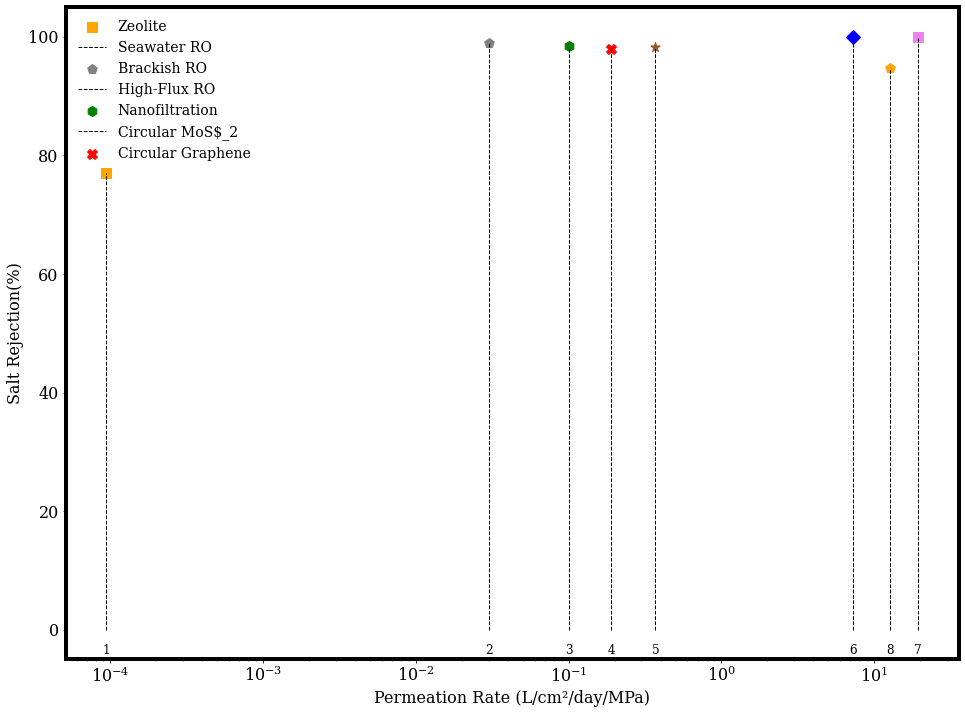

In [ ]:
import matplotlib.pyplot as plt

permeation_rate = [9.4e-5, 0.03, 0.1, 0.19, 0.37, 7.31, 19.37, 12.65]
salt_rejection = [77, 99, 98.5, 98, 98.3, 100, 100, 94.7]
markers = ["s", "p", "h", "X", "*", "D"]
colors = ["orange", "gray", "green", "red", "sienna", "blue", "violet"]
Labels = ["Zeolite", "Seawater RO", "Brackish RO", "High-Flux RO", "Nanofiltration", "Circular MoS$_2", "Circular Graphene"]

# Set the marker size (you can adjust the size as needed)
marker_size = 100
plt.figure(figsize=(16, 12))

for i in range(len(salt_rejection)):
    plt.scatter(permeation_rate[i], salt_rejection[i], color=colors[i % len(colors)],
                marker=markers[i % len(markers)], s=marker_size)

    # Draw dotted lines from each data point to the x-axis
    plt.plot([permeation_rate[i], permeation_rate[i]], [0, salt_rejection[i]], 'k--', lw=1)

    # Add the number of each data point on the x-axis
    plt.text(permeation_rate[i], -4, str(i + 1), fontsize=12, ha='center')

plt.xlabel("Permeation Rate (L/cm²/day/MPa)")
plt.ylabel("Salt Rejection(%)")

plt.xscale("log")  #
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.setp(plt.gca().spines.values(), linewidth=4)
plt.legend(Labels, loc="best", fontsize=14, frameon=False)  

plt.show()


In [ ]:
print("hj")

hj


Ion Rejection

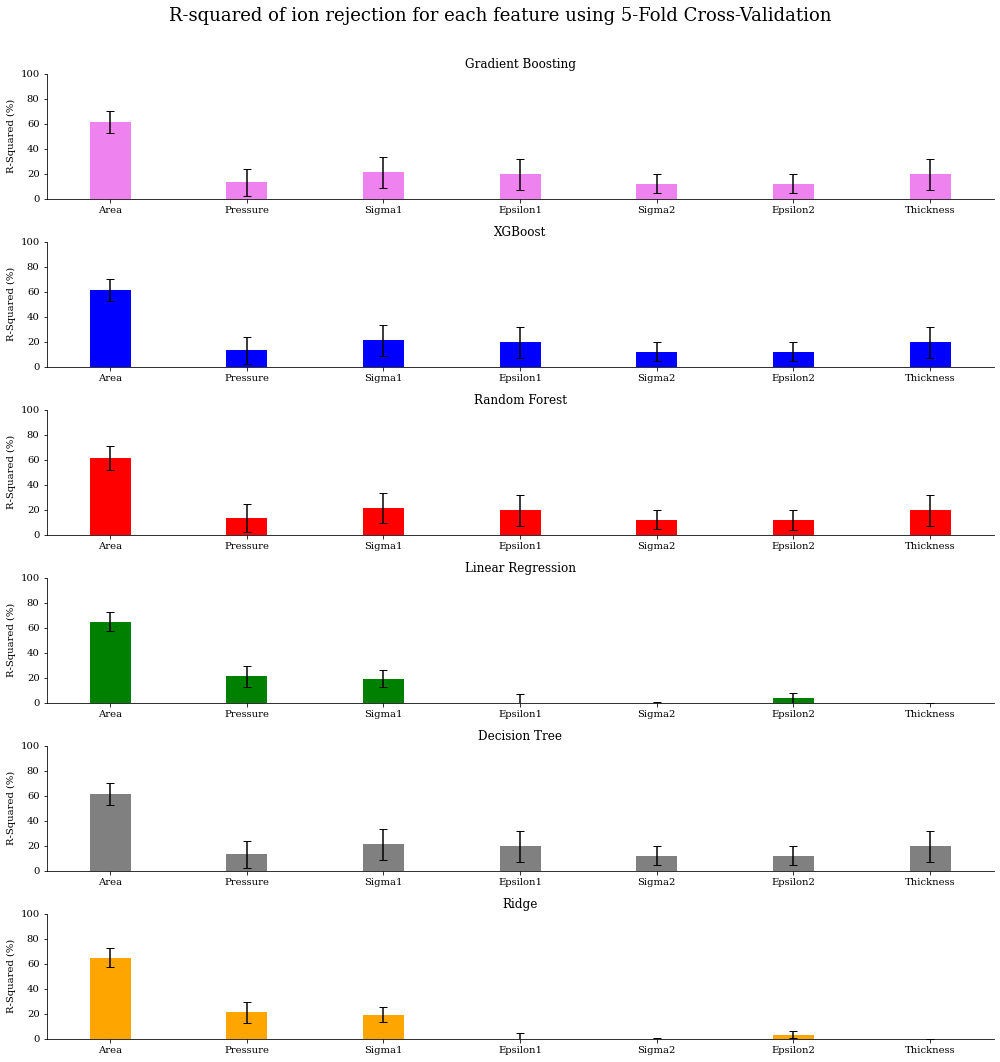

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor


plt.rc("font", size= 12, family= "serif")
data = pd.read_csv("Desalination_updated_Nov09.csv")

# Split the data into features and target variables
X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', "Thickness"]]
y_rejection = data['Rejection']

# Initialize the regression models
models = {
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Ridge": Ridge()
}

r2_values = {model_name: {feature: [] for feature in X.columns} for model_name in models}

# Perform 5-fold cross-validation and calculate R-squared for each feature
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    for feature in X.columns:
        r2_scorer = make_scorer(r2_score)
        r2 = cross_val_score(model, X[[feature]], y_rejection, cv=kf, scoring=r2_scorer)
        r2_values[model_name][feature].extend(r2)

# Create subplots for each model
fig, axes = plt.subplots(nrows=len(models), ncols=1, figsize=(14, 15))
fig.suptitle("R-squared of ion rejection for each feature using 5-Fold Cross-Validation", y=0.98,fontsize= 18)

# Plot bar charts for each feature within each model
for i, (model_name, color) in enumerate(zip(models.keys(), ['violet', 'blue', 'red', 'green', 'gray', 'orange'])):
    ax = axes[i]
    for feature in X.columns:
        r2_mean = np.mean(np.array(r2_values[model_name][feature]) * 100, axis=0)
        r2_std = np.std(np.array(r2_values[model_name][feature]) * 100, axis=0)
        ax.bar(feature, r2_mean, yerr=r2_std, width=0.3, capsize=4, color=color)
    ax.set_ylabel("R-Squared (%)")
    ax.set_title(model_name)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, 100)  # Set the y-axis limit to increase the length

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("R2_rejection_regression_features.png", dpi=600)
plt.show()

water flux

100.0


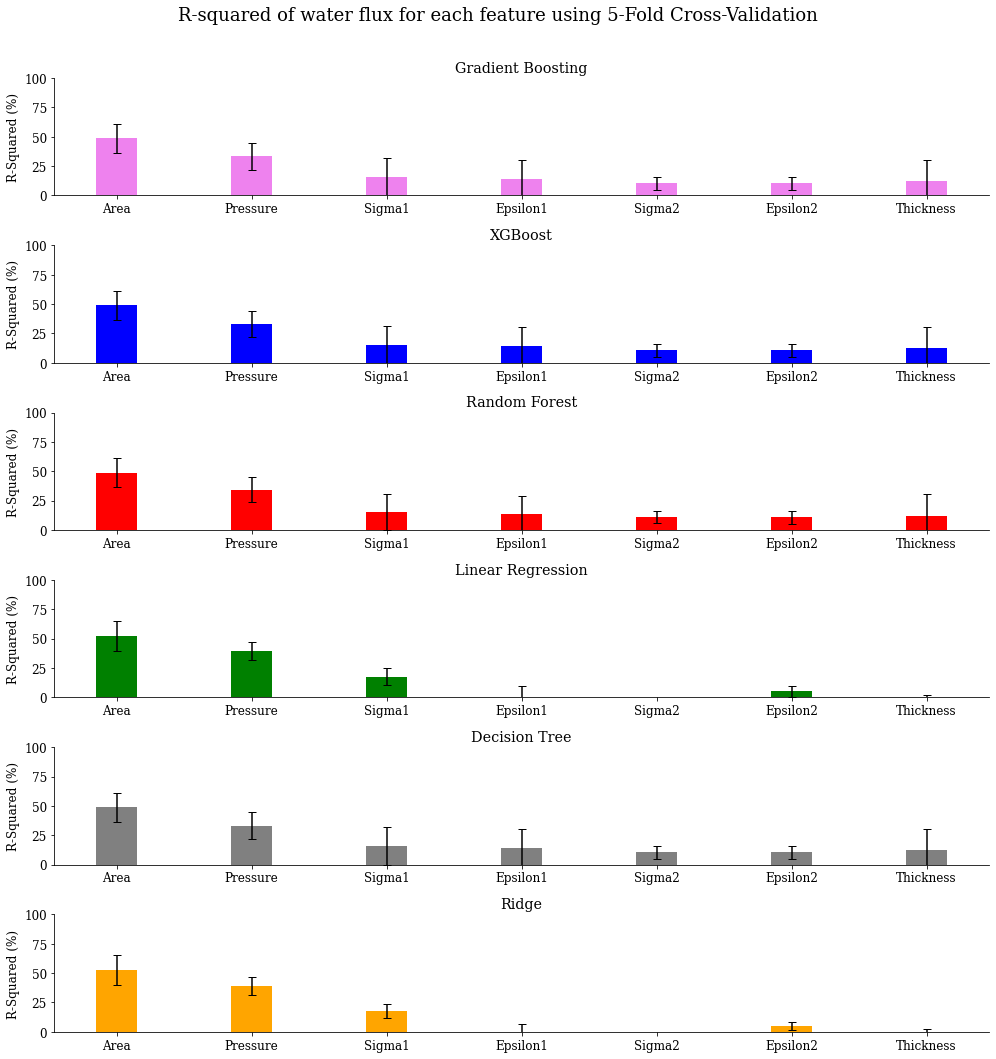

In [2]:

plt.rc("font", size= 12, family= "serif")
data = pd.read_csv("Desalination_updated_Nov09.csv")

# Split the data into features and target variables
X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', "Thickness"]]

y_Flux = data['Flux']
y_Rejection = data['Rejection']
max1= max(y_Flux)
max2= max(y_Rejection)
print(max2)
# Initialize the regression models
models = {
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Ridge": Ridge()
}

# Create lists to store R-squared values for each model and feature
r2_values = {model_name: {feature: [] for feature in X.columns} for model_name in models}

# Perform 5-fold cross-validation and calculate R-squared for each feature
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    for feature in X.columns:
        r2_scorer = make_scorer(r2_score)
        r2 = cross_val_score(model, X[[feature]], y_Flux, cv=kf, scoring=r2_scorer)
        r2_values[model_name][feature].extend(r2)

fig, axes = plt.subplots(nrows=len(models), ncols=1, figsize=(14, 15))
fig.suptitle("R-squared of water flux for each feature using 5-Fold Cross-Validation", y=0.98,fontsize= 18)

# Plot bar charts for each feature within each model
for i, (model_name, color) in enumerate(zip(models.keys(), ['violet', 'blue', 'red', 'green', 'gray', 'orange'])):
    ax = axes[i]
    for feature in X.columns:
        r2_mean = np.mean(np.array(r2_values[model_name][feature]) * 100, axis=0)
        r2_std = np.std(np.array(r2_values[model_name][feature]) * 100, axis=0)
        ax.bar(feature, r2_mean, yerr=r2_std, width=0.3, capsize=4, color=color)
    ax.set_ylabel("R-Squared (%)")
    ax.set_title(model_name)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, 100)  # Set the y-axis limit to increase the length

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("Flux_regression_features.png", dpi=600)
plt.show()

     Area  Pressure  Sigma1  Epsilon1  Sigma2  Epsilon2  Thickness  \
0      50        50   2.390    0.0692   0.000    0.0000      3.390   
1      50       100   3.390    0.0692   0.000    0.0000      3.390   
2      50       150   3.390    0.0692   0.000    0.0000      3.390   
3      50       200   3.390    0.0692   0.000    0.0000      3.390   
4      50       250   3.390    0.0692   0.000    0.0000      3.390   
..    ...       ...     ...       ...     ...       ...        ...   
100    50        50   2.829    0.0170   3.431    0.0105     10.251   
101    50       100   2.829    0.0170   3.431    0.0105     10.251   
102    50       150   2.829    0.0170   3.431    0.0105     10.251   
103    50       200   2.829    0.0170   3.431    0.0105     10.251   
104    50       250   2.829    0.0170   3.431    0.0105     10.251   

           Flux  Rejection Graphene  
0     23.280000    99.5150      NaN  
1     43.272500   100.0000      NaN  
2     62.817500    99.0325      NaN  
3     7

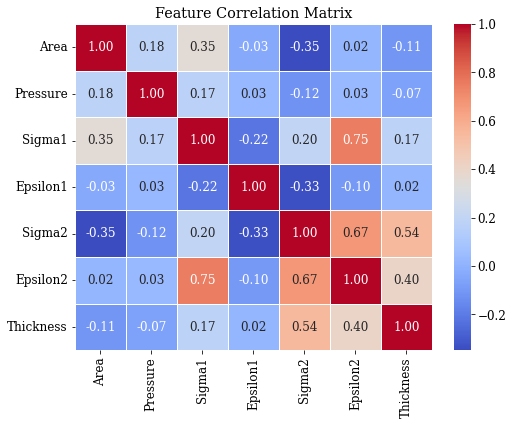

Highly correlated features: {'Epsilon2', 'Thickness'}


In [41]:
from sklearn.model_selection import train_test_split
import seaborn as sns


# Load your dataset
data = pd.read_csv('Desalination_updated_Nov09.csv')
print(data)
# Split the data into features and target variables
X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2','Thickness']]

y_flow = data['Flux']
y_rejection = data['Rejection']

# Split the data into training and testing sets
X_train, X_test, y_flow_train, y_flow_test, y_rejection_train, y_rejection_test = train_test_split(
    X, y_flow, y_rejection, test_size=0.2, random_state=42)

flow_model = LinearRegression()
flow_model.fit(X_train, y_flow_train)
flow_model.fit(X_train, y_rejection_train)
# Calculate and visualize feature correlations
correlation_matrix = X.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

correlation_threshold = 0.5
highly_correlated_features = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > correlation_threshold:
            colname = correlation_matrix.columns[i]
            highly_correlated_features.add(colname)

# Display highly correlated features
print(f"Highly correlated features: {highly_correlated_features}")

# Drop highly correlated features from the dataset
X_train_filtered = X_train.drop(columns=highly_correlated_features)


y_rejection_pred_test: 110.4619119491732
y_rejection_pred_train: 107.60588505133828


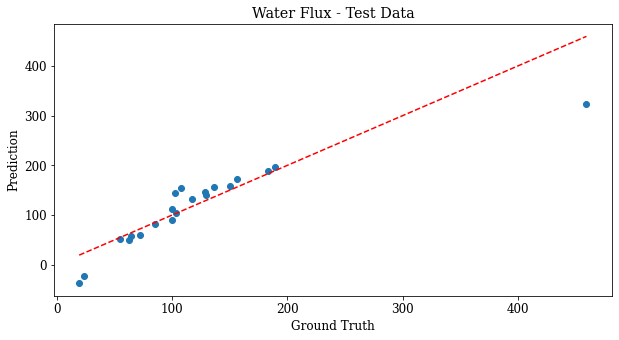

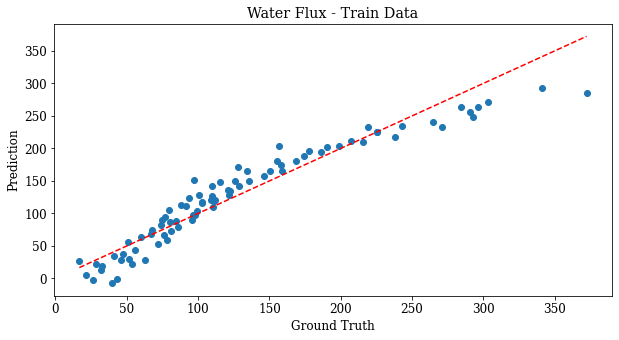

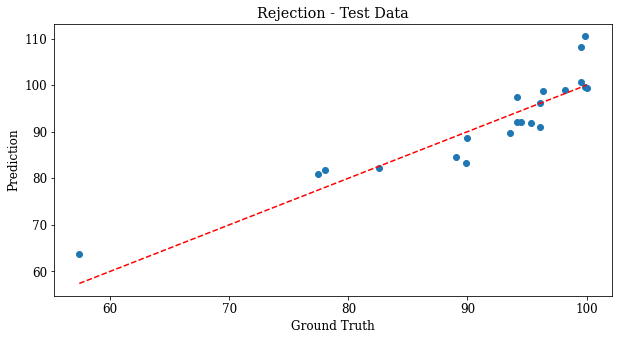

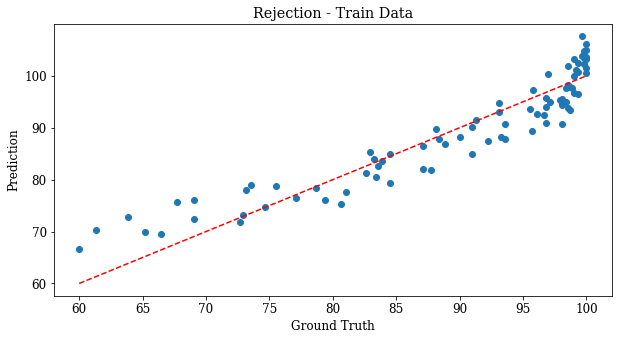

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np


# Train a linear regression model for water flux
model_flux = LinearRegression()
model_flux.fit(X_train, y_flow_train)

# Train a linear regression model for rejection
model_rejection = LinearRegression()
model_rejection.fit(X_train, y_rejection_train)

# Make predictions on the test and train data
y_flow_pred_test = model_flux.predict(X_test)
y_flow_pred_train = model_flux.predict(X_train)

y_rejection_pred_test = model_rejection.predict(X_test)
y_rejection_pred_train = model_rejection.predict(X_train)

print("y_rejection_pred_test:", max(y_rejection_pred_test))
print("y_rejection_pred_train:", max(y_rejection_pred_train))



# Plot the ground truth vs prediction for water flux (Test data)
plt.figure(figsize=(10, 5))
plt.scatter(y_flow_test, y_flow_pred_test)
plt.plot([min(y_flow_test), max(y_flow_test)], [min(y_flow_test), max(y_flow_test)], '--', color='red')
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('Water Flux - Test Data')
plt.show()

# Plot the ground truth vs prediction for water flux (Train data)
plt.figure(figsize=(10, 5))
plt.scatter(y_flow_train, y_flow_pred_train)
plt.plot([min(y_flow_train), max(y_flow_train)], [min(y_flow_train), max(y_flow_train)], '--', color='red')
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('Water Flux - Train Data')
plt.show()

# Plot the ground truth vs prediction for rejection (Test data)
plt.figure(figsize=(10, 5))
plt.scatter(y_rejection_test, y_rejection_pred_test)
plt.plot([min(y_rejection_test), max(y_rejection_test)], [min(y_rejection_test), max(y_rejection_test)], '--', color='red')
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('Rejection - Test Data')
plt.show()

# Plot the ground truth vs prediction for rejection (Train data)
plt.figure(figsize=(10, 5))
plt.scatter(y_rejection_train, y_rejection_pred_train)
plt.plot([min(y_rejection_train), max(y_rejection_train)], [min(y_rejection_train), max(y_rejection_train)], '--', color='red')
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('Rejection - Train Data')
plt.show()


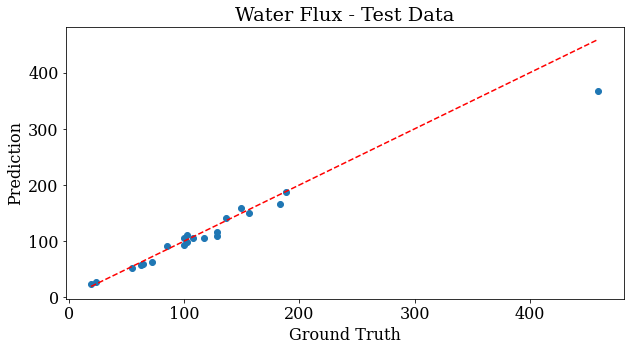

Pearson correlation coefficient (Test data) for water flux: 0.9883938386541272


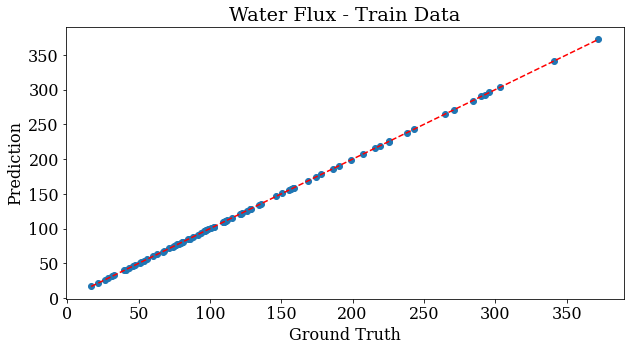

Pearson correlation coefficient (Train data) for water flux: 0.9999999802225009


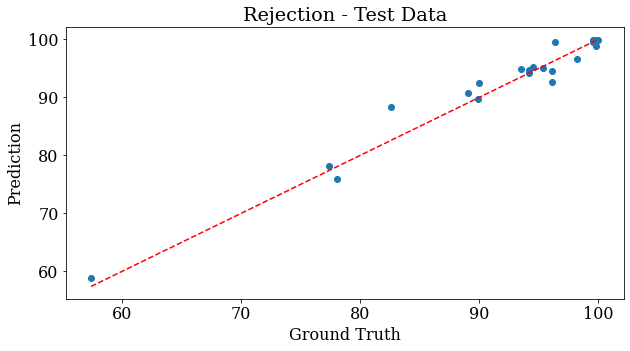

Pearson correlation coefficient (Test data) for rejection: 0.9818043411366797


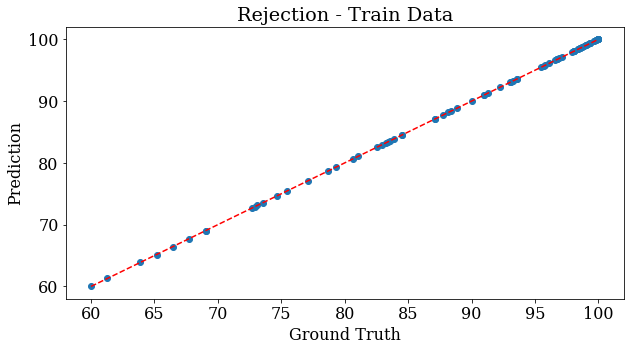

Pearson correlation coefficient (Train data) for rejection: 0.9999997417618236


In [85]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr


# Train a linear regression model for water flux
model_flux = XGBRegressor()
model_flux.fit(X_train, y_flow_train)

# Train a linear regression model for rejection
model_rejection = XGBRegressor()
model_rejection.fit(X_train, y_rejection_train)

# Make predictions on the test and train data
y_flow_pred_test = model_flux.predict(X_test)
y_flow_pred_train = model_flux.predict(X_train)

y_rejection_pred_test = model_rejection.predict(X_test)
y_rejection_pred_train = model_rejection.predict(X_train)

# Plot the ground truth vs prediction for water flux (Test data)
plt.figure(figsize=(10, 5))
plt.scatter(y_flow_test, y_flow_pred_test)
plt.plot([min(y_flow_test), max(y_flow_test)], [min(y_flow_test), max(y_flow_test)], '--', color='red')
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('Water Flux - Test Data')
plt.show()
correlation_test_flux, _ = pearsonr(y_flow_test, y_flow_pred_test)
print("Pearson correlation coefficient (Test data) for water flux:", correlation_test_flux)

# Plot the ground truth vs prediction for water flux (Train data)
plt.figure(figsize=(10, 5))
plt.scatter(y_flow_train, y_flow_pred_train)
plt.plot([min(y_flow_train), max(y_flow_train)], [min(y_flow_train), max(y_flow_train)], '--', color='red')
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('Water Flux - Train Data')
plt.show()
correlation_train_flux, _ = pearsonr(y_flow_train, y_flow_pred_train)
print("Pearson correlation coefficient (Train data) for water flux:", correlation_train_flux)

# Plot the ground truth vs prediction for rejection (Test data)
plt.figure(figsize=(10, 5))
plt.scatter(y_rejection_test, y_rejection_pred_test)
plt.plot([min(y_rejection_test), max(y_rejection_test)], [min(y_rejection_test), max(y_rejection_test)], '--', color='red')
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('Rejection - Test Data')
plt.show()
correlation_test_rejection, _ = pearsonr(y_rejection_test, y_rejection_pred_test)
print("Pearson correlation coefficient (Test data) for rejection:", correlation_test_rejection)

# Plot the ground truth vs prediction for rejection (Train data)
plt.figure(figsize=(10, 5))
plt.scatter(y_rejection_train, y_rejection_pred_train)
plt.plot([min(y_rejection_train), max(y_rejection_train)], [min(y_rejection_train), max(y_rejection_train)], '--', color='red')
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title('Rejection - Train Data')
plt.show()
correlation_train_rejection, _ = pearsonr(y_rejection_train, y_rejection_pred_train)
print("Pearson correlation coefficient (Train data) for rejection:", correlation_train_rejection)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


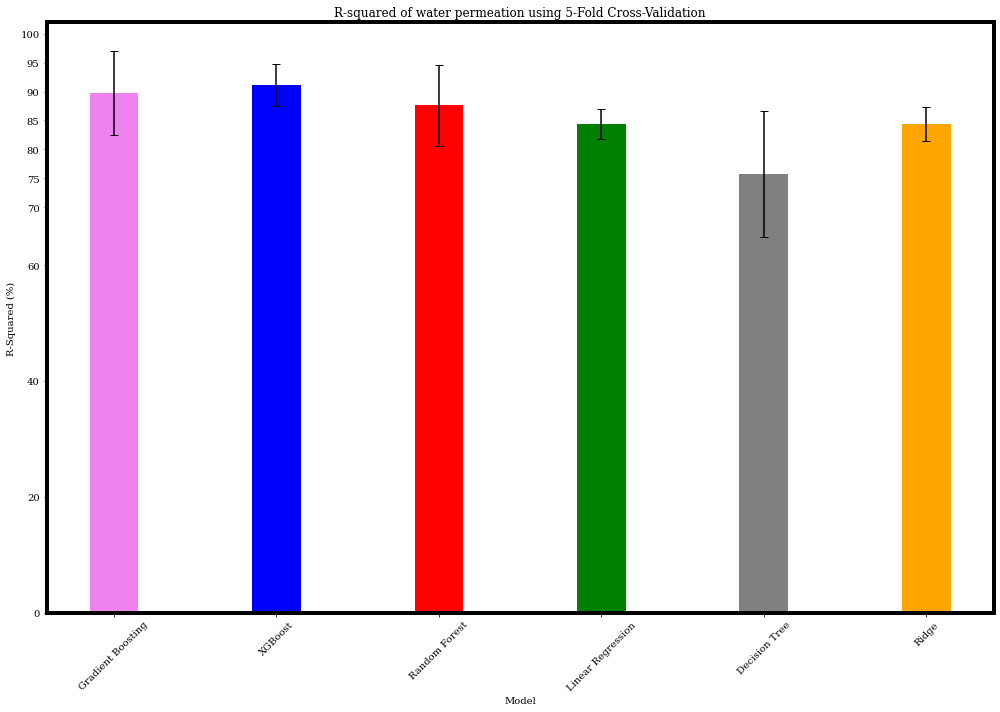

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# Load data
data = pd.read_csv("Desalination_updated_Nov09.csv")

# Calculate permeation based on the formula: permeation = rejection / 2
data['Permeation'] = data['Rejection'] / 2


# Split the data into features and target variables
X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', "Thickness"]]
y_rejection = data['Rejection']
y_flux = data['Flux']

models = {
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Ridge": Ridge()
}

# Create lists to store R-squared values for each model
r2_values = {model_name: [] for model_name in models}

# Perform 5-fold cross-validation and calculate R-squared for permeation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    r2_scorer = make_scorer(r2_score)
    r2 = cross_val_score(model, X, y_rejection, cv=kf, scoring=r2_scorer)
    r2_values[model_name].extend(r2)

r2_df_permeation = pd.DataFrame(r2_values)

plt.rc("font", size=16, family="serif")
fig, ax = plt.subplots()
bar_width = 0.3

# Plot bar charts for each model for permeation
for model_name, color in zip(models.keys(), ['violet', 'blue', 'red', 'green', 'gray', 'orange']):
    r2_mean = np.mean(np.array(r2_df_permeation[model_name]) * 100, axis=0)
    r2_std = np.std(np.array(r2_df_permeation[model_name]) * 100, axis=0)
    plt.bar(model_name, r2_mean, yerr=r2_std, width=bar_width, capsize=4, color=color)

plt.xticks(rotation=45)
plt.yticks([0,20,40,60,70,75,80,85,90,95,100])
plt.setp(plt.gca().spines.values(), linewidth=4)
fig.set_size_inches(14, 10)
plt.legend(frameon=False, loc="best")
plt.title("R-squared of water permeation using 5-Fold Cross-Validation")
plt.xlabel("Model")
plt.ylabel("R-Squared (%)")
plt.tight_layout()
plt.savefig("R2_permeation_regression.png", dpi=600)
plt.show()


     Area  Pressure  Sigma1  Epsilon1  Sigma2  Epsilon2  Thickness  \
0      50        50   2.390    0.0692   0.000    0.0000      3.390   
1      50       100   3.390    0.0692   0.000    0.0000      3.390   
2      50       150   3.390    0.0692   0.000    0.0000      3.390   
3      50       200   3.390    0.0692   0.000    0.0000      3.390   
4      50       250   3.390    0.0692   0.000    0.0000      3.390   
..    ...       ...     ...       ...     ...       ...        ...   
100    50        50   2.829    0.0170   3.431    0.0105     10.251   
101    50       100   2.829    0.0170   3.431    0.0105     10.251   
102    50       150   2.829    0.0170   3.431    0.0105     10.251   
103    50       200   2.829    0.0170   3.431    0.0105     10.251   
104    50       250   2.829    0.0170   3.431    0.0105     10.251   

           Flux  Rejection Graphene  
0     23.280000    99.5150      NaN  
1     43.272500   100.0000      NaN  
2     62.817500    99.0325      NaN  
3     7

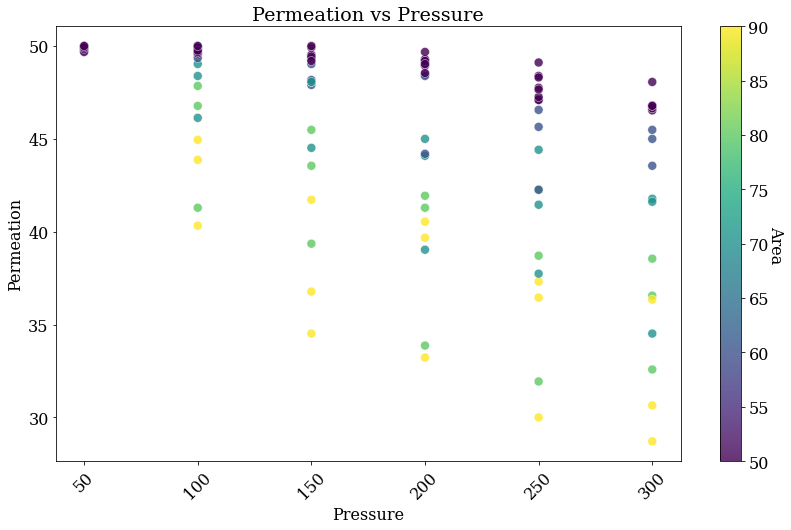

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

data = pd.read_csv("Desalination_updated_Nov09.csv")
print(data)
# Split the data into features and target variables
X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2',"Thickness"]]
y_permeation = data['Rejection'] / 2
for p, f in 
models = {
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Ridge": Ridge()
}

# Create lists to store R-squared values for each model
r2_values = {model_name: [] for model_name in models}

# Perform 5-fold cross-validation and calculate R-squared
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    r2_scorer = make_scorer(r2_score)
    r2 = cross_val_score(model, X, y_permeation, cv=kf, scoring=r2_scorer)
    r2_values[model_name].extend(r2)

# Create a DataFrame to store R-squared values
r2_df = pd.DataFrame(r2_values)

# Plotting
plt.rc("font", size=16, family="serif")
fig, ax = plt.subplots(figsize=(14, 8))

# Scatter plot with color map
sc = ax.scatter(data['Pressure'], y_permeation, c=data['Area'], cmap='viridis', alpha=0.8, edgecolors='w', linewidth=0.5, s= 80)
cbar = plt.colorbar(sc, ax=ax, label='Area')
cbar.set_label('Area', rotation=270, labelpad=15)

ax.set_xlabel("Pressure")
ax.set_ylabel("Permeation")
ax.set_title("Permeation vs Pressure")
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
plt.xticks(rotation=45)

plt.show()


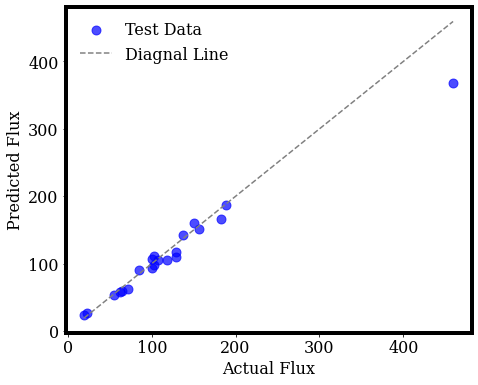

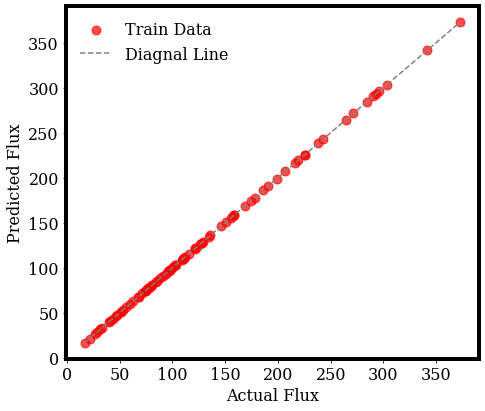

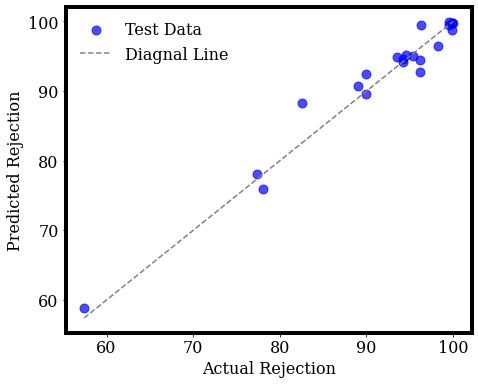

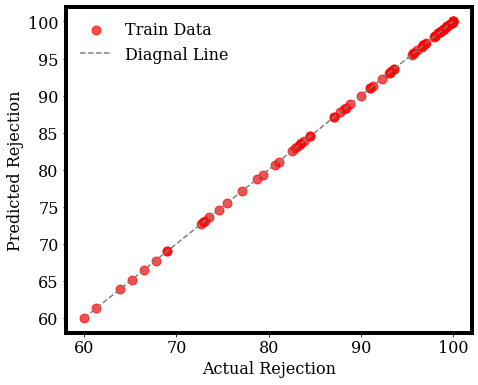

In [104]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import numpy as np


# Train a linear regression model for water flux
model_flux = XGBRegressor()
model_flux.fit(X_train, y_flow_train)

# Train a linear regression model for rejection
model_rejection = XGBRegressor()
model_rejection.fit(X_train, y_rejection_train)

# Make predictions on the test and train data
y_flow_pred_test = model_flux.predict(X_test)
y_flow_pred_train = model_flux.predict(X_train)

y_rejection_pred_test = model_rejection.predict(X_test)
y_rejection_pred_train = model_rejection.predict(X_train)

# Plot the ground truth vs prediction for water flux (Test data)
plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)
plt.scatter(y_flow_test, y_flow_pred_test, alpha= 0.7, color= "blue", label= "Test Data", s=80)
plt.plot([min(y_flow_test), max(y_flow_test)], [min(y_flow_test), max(y_flow_test)], '--', color='gray', label= "Diagnal Line")
plt.setp(plt.gca().spines.values(), linewidth=4)
plt.xlabel("Actual Flux")
plt.ylabel("Predicted Flux")
# plt.title("Flux: Ground Truth vs. Prediction (Test Data)", fontsize=17)
plt.legend(frameon=False, loc="best")
plt.show()

# Plot the ground truth vs prediction for water flux (Train data)
plt.figure(figsize=(13,6))
plt.subplot(1, 2, 2)
plt.scatter(y_flow_train, y_flow_pred_train,alpha= 0.7, color= "red", label= "Train Data", s=80)
plt.plot([min(y_flow_train), max(y_flow_train)], [min(y_flow_train), max(y_flow_train)], '--', color='gray', label= "Diagnal Line")
plt.setp(plt.gca().spines.values(), linewidth=4)
plt.xlabel("Actual Flux")
plt.ylabel("Predicted Flux")
# plt.title("Flux: Ground Truth vs. Prediction (Train Data)", fontsize=17)
plt.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()


# Plot the ground truth vs prediction for rejection (Test data)
plt.figure(figsize=(16,6))

plt.subplot(1, 2, 1)
plt.scatter(y_rejection_test, y_rejection_pred_test, alpha= 0.7, color= "blue", label= "Test Data", s=80)
plt.plot([min(y_rejection_test), max(y_rejection_test)], [min(y_rejection_test), max(y_rejection_test)], '--', color='gray', label= "Diagnal Line")
plt.setp(plt.gca().spines.values(), linewidth=4)
plt.xlabel("Actual Rejection")
plt.ylabel("Predicted Rejection")
# plt.title("Rejection: Ground Truth vs. Prediction (Test Data)", fontsize=17)
plt.legend(frameon=False, loc="best")
plt.show()

# Plot the ground truth vs prediction for rejection (Train data)
plt.figure(figsize=(16,6))
plt.subplot(1, 2, 2)
plt.scatter(y_rejection_train, y_rejection_pred_train, alpha= 0.7, color= "red", label= "Train Data", s=80)
plt.plot([min(y_rejection_train), max(y_rejection_train)], [min(y_rejection_train), max(y_rejection_train)], '--', color='gray', label= "Diagnal Line")
plt.setp(plt.gca().spines.values(), linewidth=4)
plt.xlabel("Actual Rejection")
plt.ylabel("Predicted Rejection")
# plt.title("Rejection: Ground Truth vs. Prediction (Train Data)", fontsize=17)
plt.legend(frameon=False, loc="best")
plt.show()


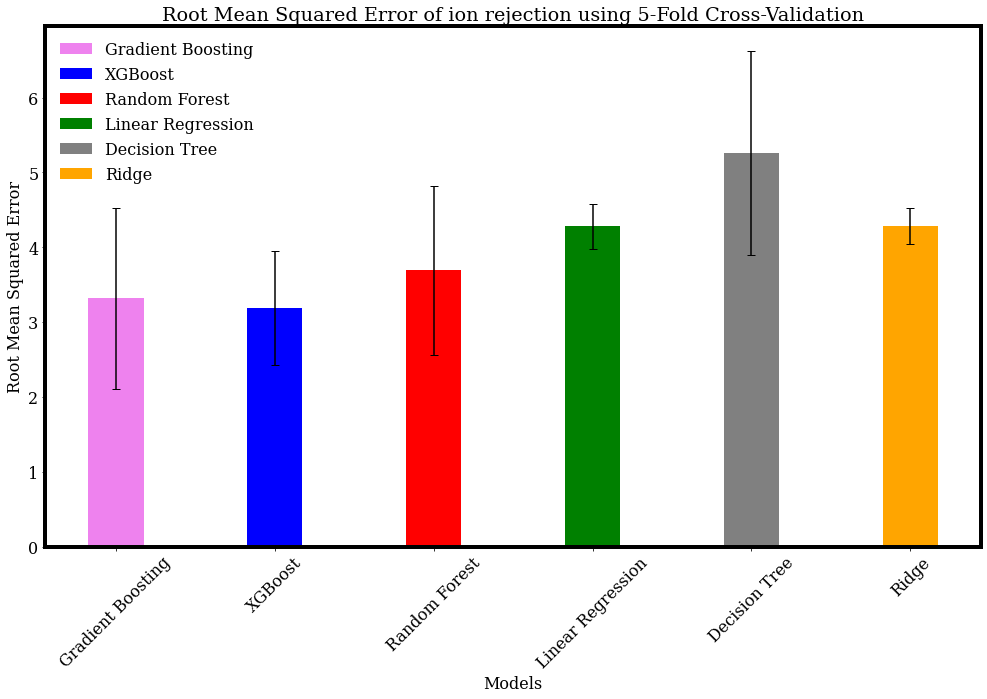

Root Mean Squared Error of ion rejection of Each Model:
Gradient Boosting: 3.3124
XGBoost: 3.1910
Random Forest: 3.8262
Linear Regression: 4.2809
Decision Tree: 5.3057
Ridge: 4.2776


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor


models = {
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Ridge": Ridge()
}

# Create lists to store RMSE values for each model
rmse_values = {model_name: [] for model_name in models}

# Perform 5-fold cross-validation and calculate RMSE
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    rmse_scorer = make_scorer(lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)))
    rmse = cross_val_score(model, X, y_rejection, cv=kf, scoring=rmse_scorer)
    rmse_values[model_name].extend(rmse)

# Create a DataFrame to store RMSE values
rmse_df = pd.DataFrame(rmse_values)

# Plotting
plt.rc("font", size=16, family="serif")
fig, ax = plt.subplots()

# Plot bar charts for each model
bar_width = 0.35
for i, (model_name, color) in enumerate(zip(models.keys(), ['violet', 'blue', 'red', 'green', 'gray', 'orange'])):
    rmse_mean = np.mean(np.array(rmse_df[model_name]), axis=0)
    rmse_std = np.std(np.array(rmse_df[model_name]), axis=0)
    plt.bar(i, rmse_mean, width=bar_width, yerr=rmse_std, capsize=4, label=model_name, color=color)

plt.xticks(range(len(models)), models.keys(), rotation=45)
plt.setp(plt.gca().spines.values(), linewidth=4)
fig.set_size_inches(14, 10)
plt.legend(frameon=False, loc="best")
plt.title("Root Mean Squared Error of ion rejection using 5-Fold Cross-Validation")
plt.xlabel("Models")
plt.ylabel("Root Mean Squared Error")
plt.tight_layout()
#plt.savefig("RMSE_rejection_regression.png", dpi=600)
plt.show()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Root Mean Squared Error of ion rejection of Each Model:")
for model_name, model in models.items():
    rmse_scorer = make_scorer(lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)))
    rmse = cross_val_score(model, X, y_rejection, cv=kf, scoring=rmse_scorer)
    rmse_values[model_name].extend(rmse)
    mean_RMSE = np.mean(rmse)

    print(f"{model_name}: {mean_RMSE:.4f}")


rmse_values: {'Gradient Boosting': [], 'XGBoost': [], 'Random Forest': [], 'Linear Regression': [], 'Decision Tree': [], 'Ridge': []}


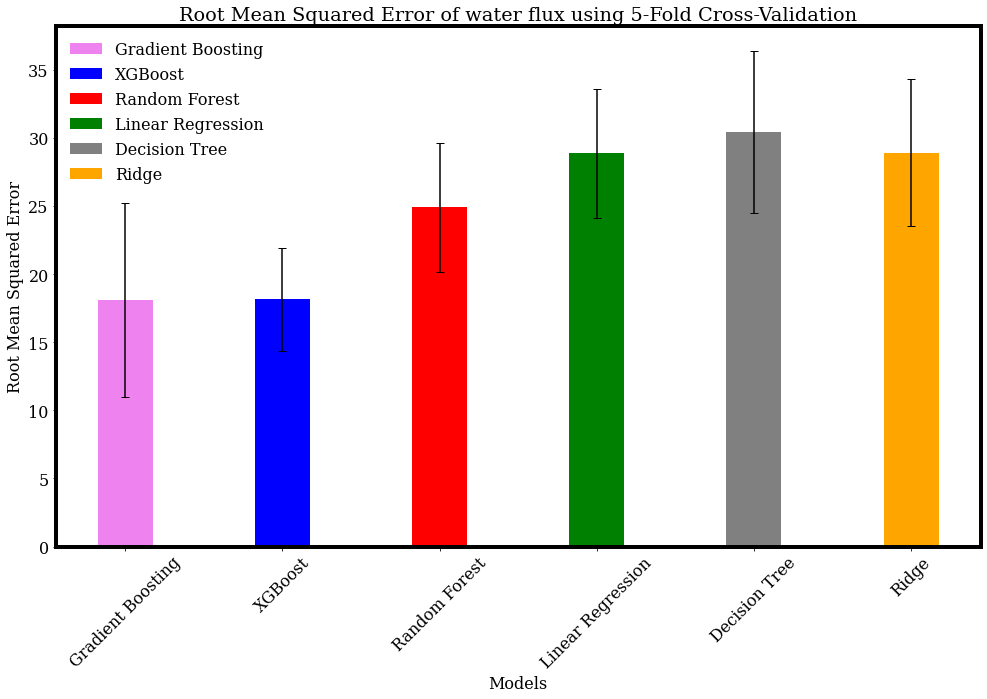

Root Mean Squared Error of Water Flux of Each Model:
Gradient Boosting: 18.1002
XGBoost: 18.1621
Random Forest: 23.9570
Linear Regression: 28.8918
Decision Tree: 30.4180
Ridge: 28.9264


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor


models = {
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Ridge": Ridge()
}

# Create lists to store RMSE values for each model
rmse_values = {model_name: [] for model_name in models}
print("rmse_values:", rmse_values)
# Perform 5-fold cross-validation and calculate RMSE
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    rmse_scorer = make_scorer(lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)))
    rmse = cross_val_score(model, X, y_Flux, cv=kf, scoring=rmse_scorer)
    rmse_values[model_name].extend(rmse)

rmse_df = pd.DataFrame(rmse_values)

# Plotting
plt.rc("font", size=16, family="serif")
fig, ax = plt.subplots()

# Plot bar charts for each model
bar_width = 0.35
for i, (model_name, color) in enumerate(zip(models.keys(), ['violet', 'blue', 'red', 'green', 'gray', 'orange'])):
    rmse_mean = np.mean(np.array(rmse_df[model_name]), axis=0)
    rmse_std = np.std(np.array(rmse_df[model_name]), axis=0)
    plt.bar(i, rmse_mean, width=bar_width, yerr=rmse_std, capsize=4, label=model_name, color=color)

plt.xticks(range(len(models)), models.keys(), rotation=45)
plt.setp(plt.gca().spines.values(), linewidth=4)
fig.set_size_inches(14, 10)
plt.legend(frameon=False, loc="best")
plt.title("Root Mean Squared Error of water flux using 5-Fold Cross-Validation")
plt.xlabel("Models")
plt.ylabel("Root Mean Squared Error")
plt.tight_layout()
#plt.savefig("RMSE_rejection_regression.png", dpi=600)
plt.show()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Root Mean Squared Error of Water Flux of Each Model:")
for model_name, model in models.items():
    rmse_scorer = make_scorer(lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)))
    rmse = cross_val_score(model, X, y_Flux, cv=kf, scoring=rmse_scorer)
    rmse_values[model_name].extend(rmse)
    mean_RMSE = np.mean(rmse)

    print(f"{model_name}: {mean_RMSE:.4f}")


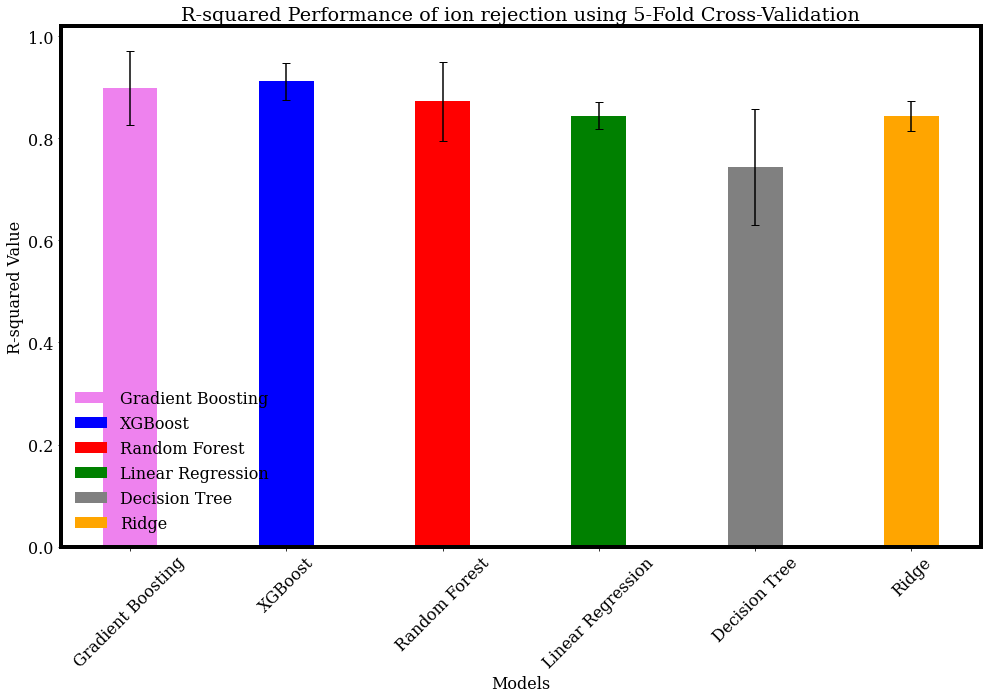

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

models = {
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Ridge": Ridge()
}

# Create a list to store R2 values and their standard deviations for each model
r2_values = {model_name: [] for model_name in models}
r2_std = {model_name: [] for model_name in models}

# Perform 5-fold cross-validation and calculate R2 and its standard deviation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    r2_scorer = make_scorer(r2_score)
    r2 = cross_val_score(model, X, y_rejection, cv=kf, scoring=r2_scorer)
    r2_values[model_name].extend(r2)
    r2_std[model_name].append(np.std(r2))  # Append single standard deviation value

# Create a DataFrame to store R2 values and their standard deviations
r2_df = pd.DataFrame(r2_values)
r2_df_std = pd.DataFrame(r2_std)

# Plotting
plt.rc("font", size=16, family="serif")
fig, ax = plt.subplots()

# Plot bar charts for each model's R2 with error bars representing standard deviations
bar_width = 0.35
for i, (model_name, color) in enumerate(zip(models.keys(), ['violet', 'blue', 'red', 'green', 'gray', 'orange'])):
    r2_mean = np.mean(np.array(r2_df[model_name]), axis=0)
    r2_std = np.mean(np.array(r2_df_std[model_name]), axis=0)
    ax.bar(i, r2_mean, width=bar_width, yerr=r2_std, capsize=4, label=model_name, color=color)

plt.xticks(range(len(models)), models.keys(), rotation=45)
plt.setp(ax.spines.values(), linewidth=4)
fig.set_size_inches(14, 10)
plt.legend(frameon=False, loc="best")
plt.title("R-squared Performance of ion rejection using 5-Fold Cross-Validation")
plt.xlabel("Models")
plt.ylabel("R-squared Value")
plt.tight_layout()
plt.show()


In [57]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

models = {
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Ridge": Ridge()
}

# Perform 5-fold cross-validation and calculate mean R2 for each model
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("R-squared Accuracy of ion rejection of Each Model:")
for model_name, model in models.items():
    r2_scorer = make_scorer(r2_score)
    r2 = cross_val_score(model, X, y_rejection, cv=kf, scoring=r2_scorer)
    mean_r2 = np.mean(r2)
    print(f"{model_name}: {mean_r2:.4f}")


R-squared Accuracy of ion rejection of Each Model:
Gradient Boosting: 0.8974
XGBoost: 0.9118
Random Forest: 0.8673
Linear Regression: 0.8441
Decision Tree: 0.7360
Ridge: 0.8441


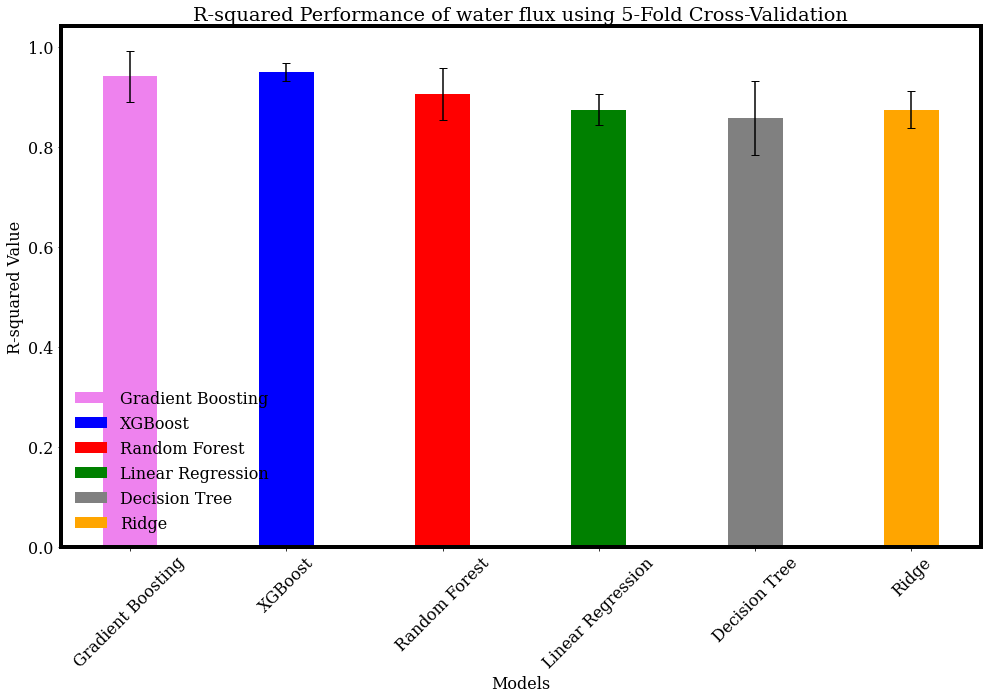

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

models = {
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Ridge": Ridge()
}

r2_values = {model_name: [] for model_name in models}
r2_std = {model_name: [] for model_name in models}

# Perform 5-fold cross-validation and calculate R2 and its standard deviation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    r2_scorer = make_scorer(r2_score)
    r2 = cross_val_score(model, X, y_flux, cv=kf, scoring=r2_scorer)
    r2_values[model_name].extend(r2)
    r2_std[model_name].append(np.std(r2))  # Append single standard deviation value

# Create a DataFrame to store R2 values and their standard deviations
r2_df = pd.DataFrame(r2_values)
r2_df_std = pd.DataFrame(r2_std)

# Plotting
plt.rc("font", size=16, family="serif")
fig, ax = plt.subplots()

# Plot bar charts for each model's R2 with error bars representing standard deviations
bar_width = 0.35
for i, (model_name, color) in enumerate(zip(models.keys(), ['violet', 'blue', 'red', 'green', 'gray', 'orange'])):
    r2_mean = np.mean(np.array(r2_df[model_name]), axis=0)
    r2_std = np.mean(np.array(r2_df_std[model_name]), axis=0)
    ax.bar(i, r2_mean, width=bar_width, yerr=r2_std, capsize=4, label=model_name, color=color)

plt.xticks(range(len(models)), models.keys(), rotation=45)
plt.setp(ax.spines.values(), linewidth=4)
fig.set_size_inches(14, 10)
plt.legend(frameon=False, loc="best")
plt.title("R-squared Performance of water flux using 5-Fold Cross-Validation")
plt.xlabel("Models")
plt.ylabel("R-squared Value")
plt.tight_layout()
plt.show()


In [5]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# Initialize the regression models
models = {
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Ridge": Ridge()
}

# Perform 5-fold cross-validation and calculate mean R2 for each model
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("R-squared Accuracy of water flux Each Model:")
for model_name, model in models.items():
    r2_scorer = make_scorer(r2_score)
    r2 = cross_val_score(model, X, y_Flux, cv=kf, scoring=r2_scorer)
    mean_r2 = np.mean(r2)
    print(f"{model_name}: {mean_r2:.4f}")


R-squared Accuracy of water flux Each Model:
Gradient Boosting: 0.9403
XGBoost: 0.9489
Random Forest: 0.9046
Linear Regression: 0.8739
Decision Tree: 0.8504
Ridge: 0.8738


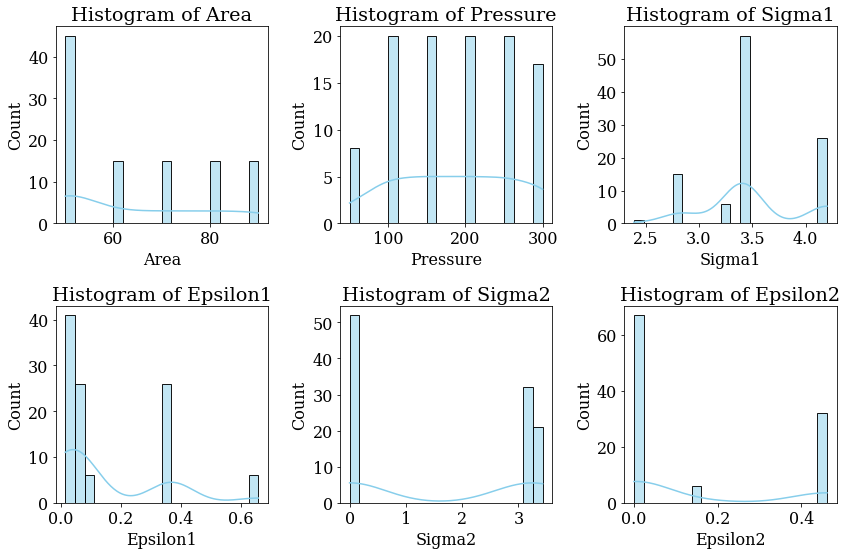

LinearRegression()

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('/Users/omidbarati/Documents/MD/Water_Desalination/Code/Desalination_updated_Nov09.csv')

# Split the data into features and target variables
X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2']]
y_flow = data['Flux']
y_rejection = data['Rejection']

# Plot histograms of Gaussian distributions for each feature
plt.figure(figsize=(12, 8))
for i, column in enumerate(X.columns):
    plt.subplot(2, 3, i+1)
    sns.histplot(X[column], kde=True, color='skyblue', bins=20)
    plt.title(f'Histogram of {column}')

plt.tight_layout()
plt.show()

# Split the data into training and testing sets
X_train, X_test, y_flow_train, y_flow_test, y_rejection_train, y_rejection_test = train_test_split(
    X, y_flow, y_rejection, test_size=0.2, random_state=42)

# Create a Linear Regression model for Flow
flow_model = LinearRegression()
flow_model.fit(X_train, y_flow_train)


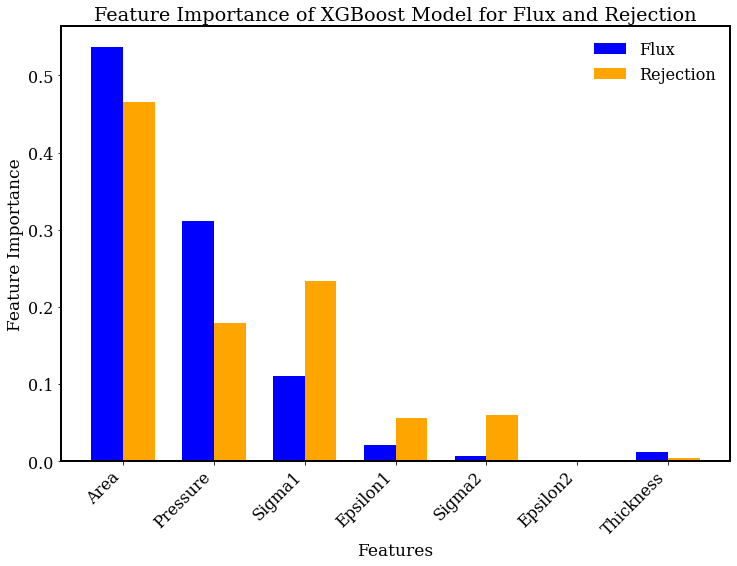

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('Desalination_updated_Nov09.csv')

# Split the data into features and target variables
X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', 'Thickness']]
y_flow = data['Flux']
y_rejection = data['Rejection']

# Split the data into training and testing sets
X_train, X_test, y_flow_train, y_flow_test, y_rejection_train, y_rejection_test = train_test_split(
    X, y_flow, y_rejection, test_size=0.2, random_state=42)

# Create an XGBoost model for Flow
xgb_model_flow = XGBRegressor()
xgb_model_flow.fit(X_train, y_flow_train)

# Create an XGBoost model for Rejection
xgb_model_rejection = XGBRegressor()
xgb_model_rejection.fit(X_train, y_rejection_train)

# Get feature importance for Flow
feature_importance_flow = xgb_model_flow.feature_importances_

# Get feature importance for Rejection
feature_importance_rejection = xgb_model_rejection.feature_importances_

# Plot feature importance for both Flow and Rejection
fig, ax = plt.subplots(figsize=(12, 8))

bar_width = 0.35
index = np.arange(len(X.columns))

bar1 = ax.bar(index, feature_importance_flow, bar_width, label='Flux', color='blue')
bar2 = ax.bar(index + bar_width, feature_importance_rejection, bar_width, label='Rejection', color='orange')
plt.rc("font", size=16, family="serif")

ax.set_xlabel('Features',fontsize= 17)
ax.set_ylabel('Feature Importance', fontsize= 17)
ax.set_title('Feature Importance of XGBoost Model for Flux and Rejection')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(X.columns, rotation=45, ha='right')
plt.setp(plt.gca().spines.values(), linewidth=2)
ax.legend(frameon=False)

plt.show()


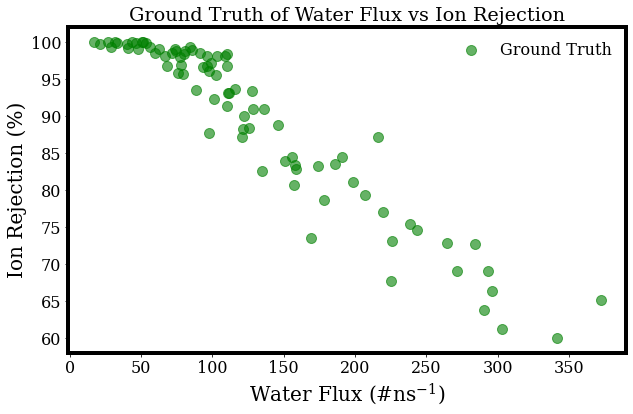

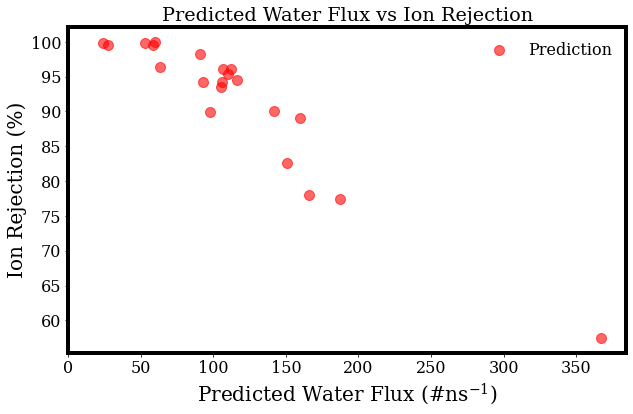

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

data = pd.read_csv('Desalination_updated_Nov09.csv')

X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', "Thickness"]]
y_flow = data['Flux']
y_rejection = data['Rejection']

# Split the data into training and testing sets
X_train, X_test, y_flow_train, y_flow_test, y_rejection_train, y_rejection_test = train_test_split(
    X, y_flow, y_rejection, test_size=0.2, random_state=42)

# Create an XGBoost model for Flow
xgb_model_flow = XGBRegressor()
xgb_model_flow.fit(X_train, y_flow_train)

# Predictions for the testing set
y_flow_pred = xgb_model_flow.predict(X_test)

# Plot the ground truth of water flux vs ion rejection
plt.figure(figsize=(10, 6))
plt.setp(plt.gca().spines.values(), linewidth=4)
plt.scatter( y_flow_train, y_rejection_train, color='g', label='Ground Truth', s=100, alpha= 0.6)
plt.xlabel('Water Flux (#$\mathregular{ns^{-1}}$)',fontsize= 20)
plt.ylabel('Ion Rejection (%)', fontsize= 20)
plt.title('Ground Truth of Water Flux vs Ion Rejection')
plt.legend(frameon= False)
plt.show()

# Plot the predicted water flux vs ion rejection
plt.figure(figsize=(10, 6))
plt.setp(plt.gca().spines.values(), linewidth=4)
plt.scatter(y_flow_pred, y_rejection_test, color='red', label='Prediction', s=100, alpha= 0.6)
plt.xlabel('Predicted Water Flux (#$\mathregular{ns^{-1}}$)',fontsize= 20)
plt.ylabel('Ion Rejection (%)',fontsize= 20)
plt.xticks([0,50,100,150,200,250,300,350])
plt.yticks([60,65,70,75,80,85,90,95,100])
plt.title('Predicted Water Flux vs Ion Rejection')
plt.legend(frameon=False)
plt.show()


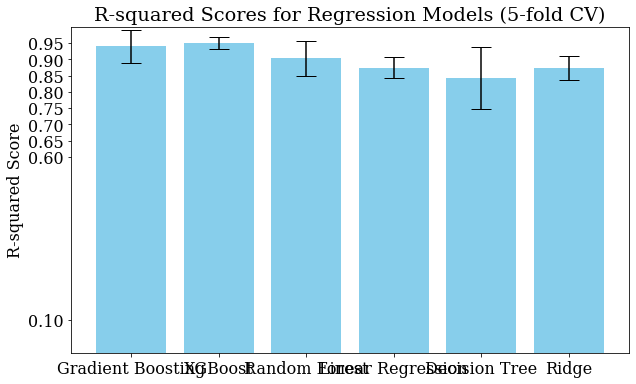

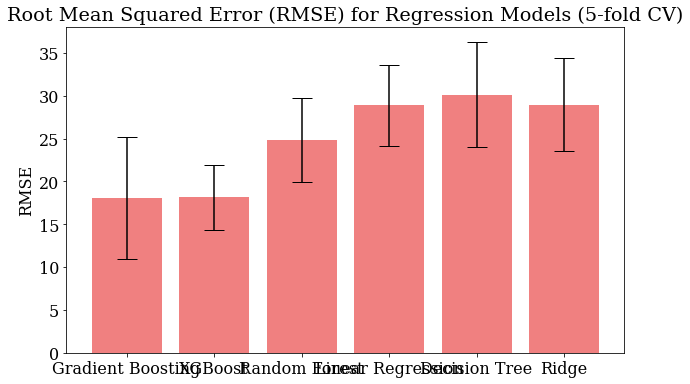

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

data = pd.read_csv("Desalination_updated_Nov09.csv")

X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', 'Thickness']]
y_rejection = data['Flux']

# Initialize the regression models
models = {
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Ridge": Ridge()
}

# Function to calculate RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

model_names = []
r2_means = []
r2_stds = []
rmse_means = []
rmse_stds = []

# Set up 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Loop through models
for model_name, model in models.items():
    # Calculate R-squared using 5-fold cross-validation
    r2_scores = cross_val_score(model, X, y_rejection, cv=kf, scoring=make_scorer(r2_score))
    r2_means.append(r2_scores.mean())
    r2_stds.append(r2_scores.std())
    
    # Add model name to the list
    model_names.append(model_name)

    # Calculate RMSE using 5-fold cross-validation
    rmse_scores = cross_val_score(model, X, y_rejection, cv=kf, scoring=make_scorer(rmse))
    rmse_means.append(rmse_scores.mean())
    rmse_stds.append(rmse_scores.std())

# Plotting R-squared scores with error bars
plt.figure(figsize=(10, 6))
plt.bar(model_names, r2_means, yerr=r2_stds, color='skyblue', capsize=10)
plt.title('R-squared Scores for Regression Models (5-fold CV)')
plt.yticks([.60,.65,.70,.75,.80,.85,.90,.95,.100])

plt.ylabel('R-squared Score')
plt.ylim(0, 1)
plt.show()

# Plotting RMSE scores with error bars
plt.figure(figsize=(10, 6))
plt.bar(model_names, rmse_means, yerr=rmse_stds, color='lightcoral', capsize=10)
plt.title('Root Mean Squared Error (RMSE) for Regression Models (5-fold CV)')
plt.ylabel('RMSE')
plt.show()


In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor  # You can choose any regression model here
from sklearn.metrics import mean_squared_error

data = pd.read_csv("Desalination_updated_Nov09.csv")

# Split the data into features and target variable
X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', 'Thickness']]
y_Flux = data['Flux']
y_rejection = data['Rejection']
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the regression model
model = RandomForestRegressor() 
model.fit(X_train, y_train)

# Evaluate the model on the testing set
y_pred = model.predict(X_test)
# mse = mean_squared_error(y_test, y_pred)
# print("Mean Squared Error on test set:", mse)

# Fixed input numbers
Flux_input = [[50,100,2.39,0.0692,0,0,3.39]]

# Predict output target for fixed input
predicted_output = model.predict(Flux_input)
print("Predicted output Flux:", predicted_output)


Predicted output Flux: [114.27965]


/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Load data
data = pd.read_csv("Desalination_updated_Nov09.csv")

# Split the data into features and target variables
X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', 'Thickness']]
y_Flux = data['Flux']
y_rejection = data['Rejection']

# Split data into training and testing sets
X_train, X_test, y_train_Flux, y_test_Flux, y_train_rejection, y_test_rejection = train_test_split(X, y_Flux, y_rejection, test_size=0.2, random_state=42)

model_Flux = RandomForestRegressor() 
model_Flux.fit(X_train, y_train_Flux)

model_rejection = RandomForestRegressor() 
model_rejection.fit(X_train, y_train_rejection)

# Fixed input numbers
fixed_input = [[50,100,2.39,0.0692,0,0,3.39]]

# Predict output targets for fixed input
predicted_output_Flux = model_Flux.predict(fixed_input)
predicted_output_rejection = model_rejection.predict(fixed_input)

print("Predicted output target (Flux):", predicted_output_Flux)
print("Predicted output target (Rejection):", predicted_output_rejection)


Predicted output target (Flux): [47.04534836]
Predicted output target (Rejection): [99.74485]


/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.w

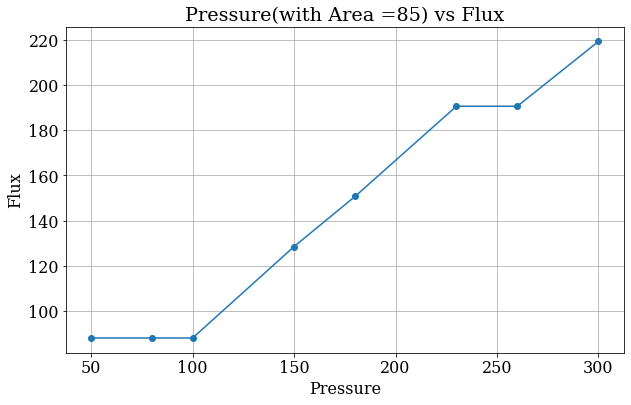

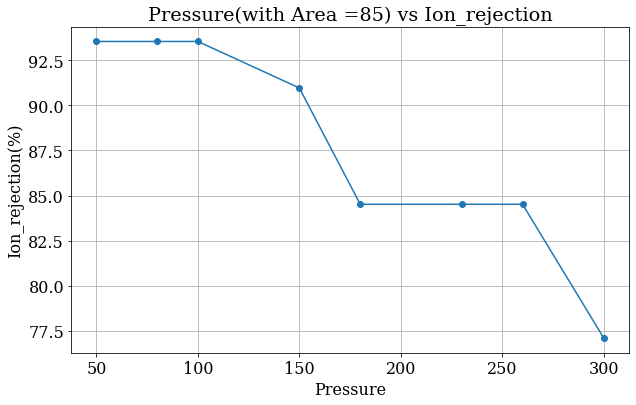

In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load data
data = pd.read_csv("Desalination_updated_Nov09.csv")

# Split the data into features and target variables
X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', 'Thickness']]
y_Flux = data['Flux']
y_rejection = data['Rejection']

# Split data into training and testing sets
X_train, X_test, y_train_Flux, y_test_Flux, y_train_rejection, y_test_rejection = train_test_split(X, y_Flux, y_rejection, test_size=0.2, random_state=42)

# Initialize and train the regression model for Flux
model_Flux = DecisionTreeRegressor()
model_Flux.fit(X_train, y_train_Flux)

model_Rejection = DecisionTreeRegressor()
model_Rejection.fit(X_train, y_train_rejection)

# Fixed input numbers
fixed_input = [[85, 100, 3.39, 0.0692, 0, 0, 3.39]]

# Different input pressures
input_pressures55 = [50,80,100,150,180,230,260,300]

# Predict Flux for each input pressure
predicted_fluxes55 = []
predicted_rejection55 = []
for pressure in input_pressures100:
    fixed_input[0][1] = pressure  # Update the pressure in fixed input
    predicted_flux = model_Flux.predict(fixed_input)
    predicted_fluxes55.append(predicted_flux[0])
    predicted_rejection = model_Rejection.predict(fixed_input)
    predicted_rejection55.append(predicted_rejection[0])

# for pressure in input_pressures100:
#     fixed_input[0][1] = pressure  # Update the pressure in fixed input
#     predicted_flux = model_Flux.predict(fixed_input)
#     predicted_fluxes100.append(predicted_flux[0])

# Plot Pressure vs Flux
plt.figure(figsize=(10, 6))
plt.plot(input_pressures55, predicted_fluxes55, marker='o', linestyle='-')
plt.title('Pressure(with Area =85) vs Flux')
plt.xlabel('Pressure')
plt.ylabel('Flux')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(input_pressures55, predicted_rejection55, marker='o', linestyle='-')
plt.title('Pressure(with Area =85) vs Ion_rejection')
plt.xlabel('Pressure')
plt.ylabel('Ion_rejection(%)')
plt.grid(True)
plt.show()


/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.w

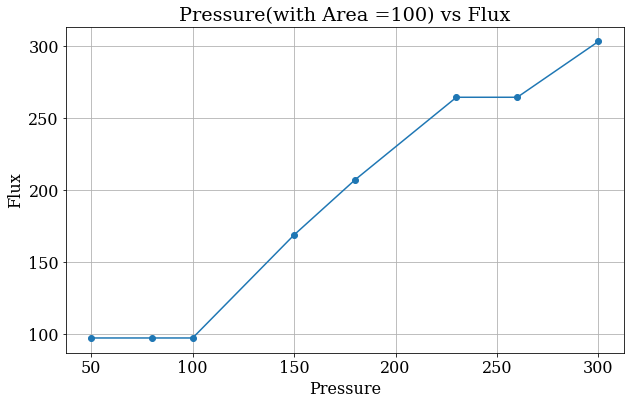

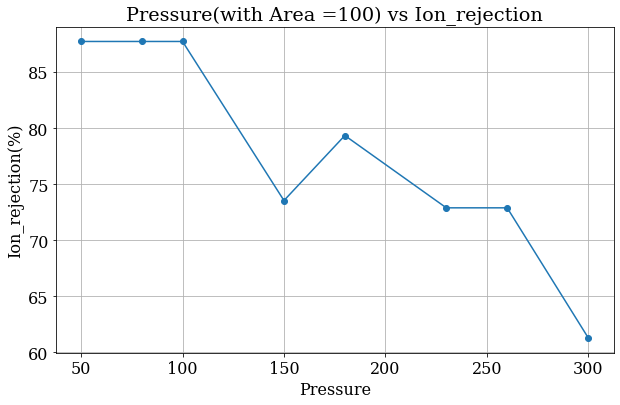

In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load data
data = pd.read_csv("Desalination_updated_Nov09.csv")

# Split the data into features and target variables
X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', 'Thickness']]
y_Flux = data['Flux']
y_rejection = data['Rejection']

# Split data into training and testing sets
X_train, X_test, y_train_Flux, y_test_Flux, y_train_rejection, y_test_rejection = train_test_split(X, y_Flux, y_rejection, test_size=0.2, random_state=42)

# Initialize and train the regression model for Flux
model_Flux = DecisionTreeRegressor()
model_Flux.fit(X_train, y_train_Flux)

model_Rejection = DecisionTreeRegressor()
model_Rejection.fit(X_train, y_train_rejection)

# Fixed input numbers
fixed_input = [[100, 100, 3.39, 0.0692, 0, 0, 3.39]]

# Different input pressures
input_pressures100 = [50,80,100,150,180,230,260,300]

# Predict Flux for each input pressure
predicted_fluxes100 = []
predicted_rejection100 = []
for pressure in input_pressures100:
    fixed_input[0][1] = pressure  # Update the pressure in fixed input
    predicted_flux = model_Flux.predict(fixed_input)
    predicted_fluxes100.append(predicted_flux[0])
    predicted_rejection = model_Rejection.predict(fixed_input)
    predicted_rejection100.append(predicted_rejection[0])

# for pressure in input_pressures100:
#     fixed_input[0][1] = pressure  # Update the pressure in fixed input
#     predicted_flux = model_Flux.predict(fixed_input)
#     predicted_fluxes100.append(predicted_flux[0])

# Plot Pressure vs Flux
plt.figure(figsize=(10, 6))
plt.plot(input_pressures100, predicted_fluxes100, marker='o', linestyle='-')
plt.title('Pressure(with Area =100) vs Flux')
plt.xlabel('Pressure')
plt.ylabel('Flux')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(input_pressures100, predicted_rejection100, marker='o', linestyle='-')
plt.title('Pressure(with Area =100) vs Ion_rejection')
plt.xlabel('Pressure')
plt.ylabel('Ion_rejection(%)')
plt.grid(True)
plt.show()


/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.w

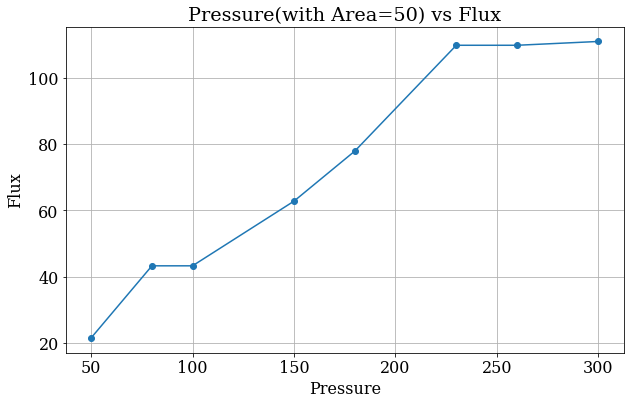

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

data = pd.read_csv("Desalination_updated_Nov09.csv")

X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', 'Thickness']]
y_Flux = data['Flux']
y_rejection = data['Rejection']

X_train, X_test, y_train_Flux, y_test_Flux, y_train_rejection, y_test_rejection = train_test_split(X, y_Flux, y_rejection, test_size=0.2, random_state=42)

# Initialize and train the regression model for Flux
model_Flux = DecisionTreeRegressor()
model_Flux.fit(X_train, y_train_Flux)

model_Rejection = DecisionTreeRegressor()
model_Rejection.fit(X_train, y_train_rejection)

# Fixed input numbers
fixed_input = [[50, 100, 3.39, 0.0692, 0, 0, 3.39]]

# Different input pressures
input_pressures50 = [50,80,100,150,180, 230,260,300]

# Predict Flux for each input pressure
predicted_fluxes50 = []
predicted_rejection50 = []
for pressure in input_pressures50:
    fixed_input[0][1] = pressure  # Update the pressure in fixed input
    predicted_flux = model_Flux.predict(fixed_input)
    predicted_fluxes50.append(predicted_flux[0])
    predicted_rejection = model_Rejection.predict(fixed_input)
    predicted_rejection50.append(predicted_rejection[0])

# Plot Pressure vs Flux
plt.figure(figsize=(10, 6))
plt.plot(input_pressures50, predicted_fluxes50, marker='o', linestyle='-')
plt.title('Pressure(with Area=50) vs Flux')
plt.xlabel('Pressure')
plt.ylabel('Flux')
plt.grid(True)
plt.show()


/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.w

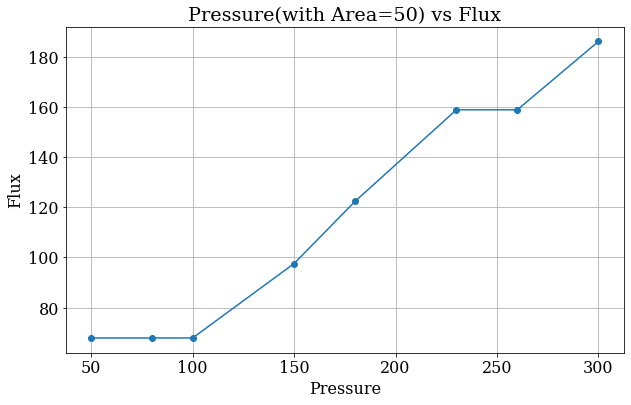

In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load data
data = pd.read_csv("Desalination_updated_Nov09.csv")

# Split the data into features and target variables
X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', 'Thickness']]
y_Flux = data['Flux']
y_rejection = data['Rejection']

# Split data into training and testing sets
X_train, X_test, y_train_Flux, y_test_Flux, y_train_rejection, y_test_rejection = train_test_split(X, y_Flux, y_rejection, test_size=0.2, random_state=42)

model_Flux = DecisionTreeRegressor()
model_Flux.fit(X_train, y_train_Flux)

model_Rejection = DecisionTreeRegressor()
model_Rejection.fit(X_train, y_train_rejection)

fixed_input = [[75, 100, 3.39, 0.0692, 0, 0, 3.39]]

# Different input pressures
input_pressures75 = [50,80,100,150,180, 230,260,300]

# Predict Flux for each input pressure
predicted_fluxes75 = []
predicted_rejection75 = []
for pressure in input_pressures75:
    fixed_input[0][1] = pressure  # Update the pressure in fixed input
    predicted_flux = model_Flux.predict(fixed_input)
    predicted_fluxes75.append(predicted_flux[0])
    predicted_rejection = model_Rejection.predict(fixed_input)
    predicted_rejection75.append(predicted_rejection[0])

# Plot Pressure vs Flux
plt.figure(figsize=(10, 6))
plt.plot(input_pressures75, predicted_fluxes75, marker='o', linestyle='-')
plt.title('Pressure(with Area=50) vs Flux')
plt.xlabel('Pressure')
plt.ylabel('Flux')
plt.grid(True)
plt.show()


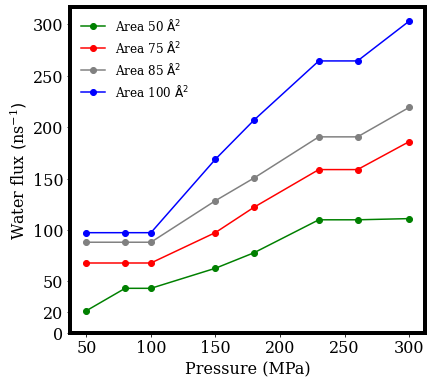

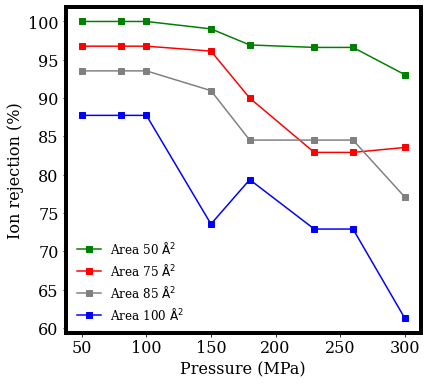

In [242]:
# Flux
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(input_pressures50, predicted_fluxes50, marker='o', linestyle='-', color= "g", label= "Area 50 $\mathrm{\AA^2}$")
plt.plot(input_pressures75, predicted_fluxes75, marker='o', linestyle='-', color= "red", label= "Area 75 $\mathrm{\AA^2}$")
plt.plot(input_pressures55, predicted_fluxes55, marker='o', linestyle='-', color= "gray", label= "Area 85 $\mathrm{\AA^2}$")
plt.plot(input_pressures100, predicted_fluxes100, marker='o', linestyle='-', color= "b", label= "Area 100 $\mathrm{\AA^2}$")
plt.yticks([0,20,50,100,150,200,250,300])
plt.setp(plt.gca().spines.values(), linewidth=4)
# plt.title('Pressure vs Flux Prediction')
plt.xlabel('Pressure (MPa)')
plt.ylabel('Water flux $(\mathregular{ns^{-1}})$')
# plt.grid(True)
plt.legend(frameon=False, fontsize= 12)
# Ion_Rejection
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 2)
plt.plot(input_pressures50, predicted_rejection50, marker='s', linestyle='-', color= "g", label= "Area 50 $\mathrm{\AA^2}$")
plt.plot(input_pressures75, predicted_rejection75, marker='s', linestyle='-', color= "red", label= "Area 75 $\mathrm{\AA^2}$")
plt.plot(input_pressures55, predicted_rejection55, marker='s', linestyle='-', color= "gray", label= "Area 85 $\mathrm{\AA^2}$")
plt.plot(input_pressures100, predicted_rejection100, marker='s', linestyle='-', color= "b", label= "Area 100 $\mathrm{\AA^2}$")
# plt.yticks([0,20,50,100,150,200,250,300])
plt.setp(plt.gca().spines.values(), linewidth=4)
plt.xlabel('Pressure (MPa)')
plt.ylabel('Ion rejection (%)')
# plt.grid(True)
plt.legend(frameon=False, fontsize= 12)
plt.show()

/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Users/omidbarati/miniconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.w

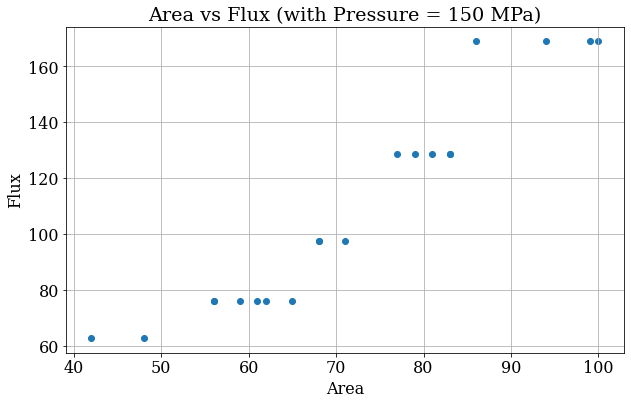

In [240]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor 

data = pd.read_csv("Desalination_updated_Nov09.csv")

X = data[['Area', 'Pressure', 'Sigma1', 'Epsilon1', 'Sigma2', 'Epsilon2', 'Thickness']]
y_Flux = data['Flux']
y_rejection = data['Rejection']

X_train, X_test, y_train_Flux, y_test_Flux = train_test_split(X, y_Flux, test_size=0.2, random_state=42)

model_Flux = DecisionTreeRegressor()  # Use XGBRegressor
model_Flux.fit(X_train, y_train_Flux)

# Different input areas
input_areas = np.random.randint(40, 101, size=20)  # Generate 10 random numbers between 50 and 100

# Fixed input numbers
fixed_input = [[80, 150, 3.39, 0.0692, 0, 0, 3.39]]  # Using Area=100

# Predict Flux for each input area
predicted_fluxes = []
for area in input_areas:
    fixed_input[0][0] = area  # Update the area in fixed input
    predicted_flux = model_Flux.predict(fixed_input)
    predicted_fluxes.append(predicted_flux[0])

# Plot Area vs Flux
plt.figure(figsize=(10, 6))
plt.scatter(input_areas, predicted_fluxes, marker='o', linestyle='-')
plt.title('Area vs Flux (with Pressure = 150 MPa)')
plt.xlabel('Area')
plt.ylabel('Flux')
plt.grid(True)
plt.show()


Model: Gradient Boosting


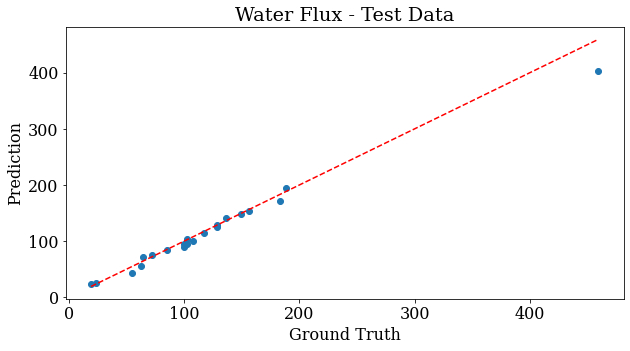

Pearson correlation coefficient (Test data): 0.9950747846949735


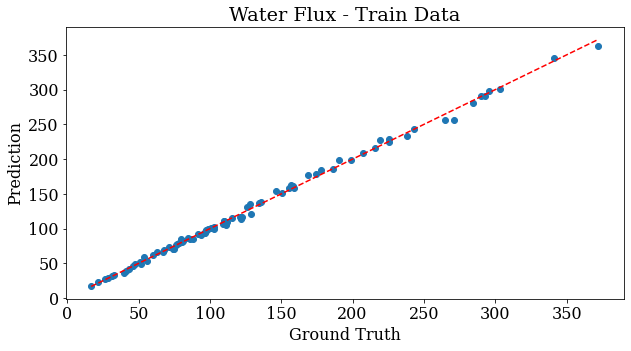

Pearson correlation coefficient (Train data): 0.9987568007900615


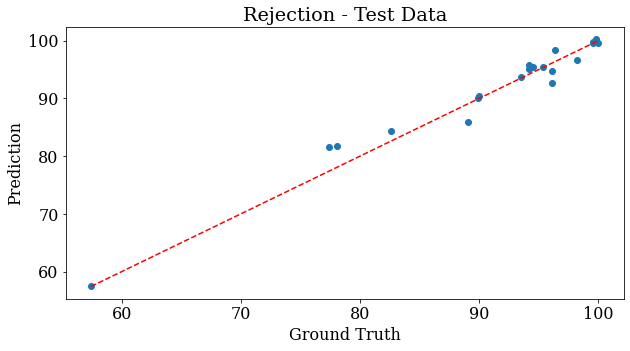

Pearson correlation coefficient (Test data): 0.9846654850837822


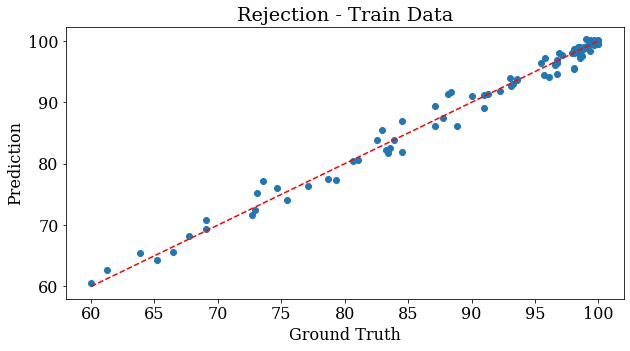

Pearson correlation coefficient (Train data): 0.9932981708549705
Model: XGBoost


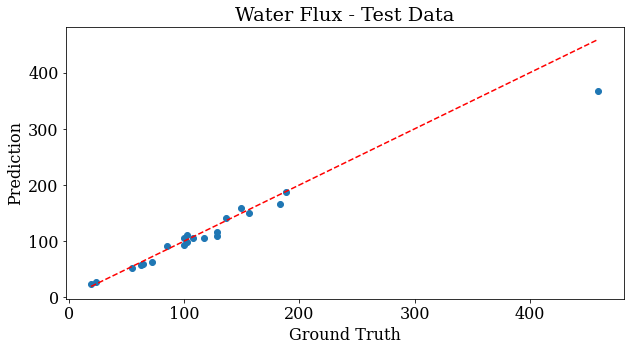

Pearson correlation coefficient (Test data): 0.9883938386541272


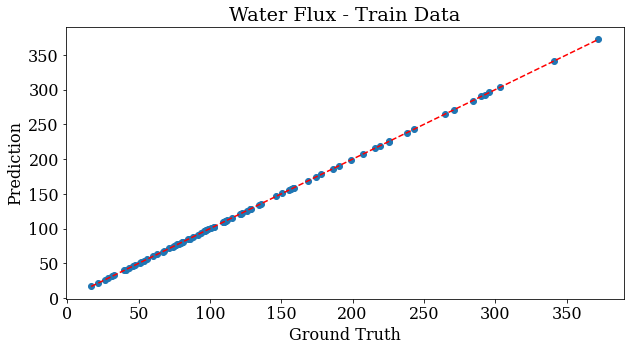

Pearson correlation coefficient (Train data): 0.9999999802225009


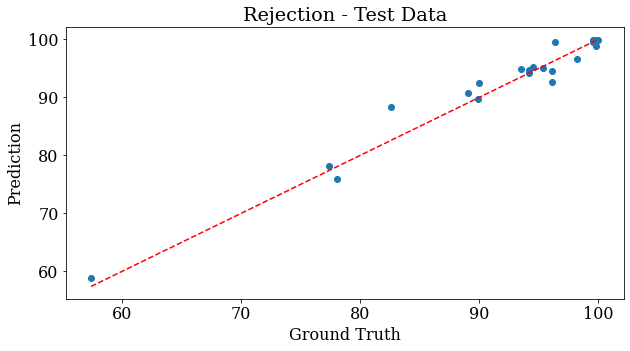

Pearson correlation coefficient (Test data): 0.9818043411366797


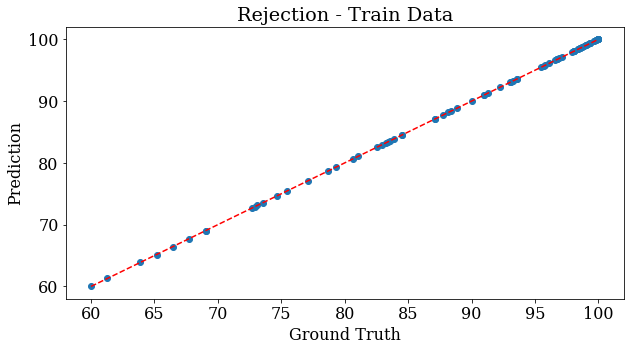

Pearson correlation coefficient (Train data): 0.9999997417618236
Model: Random Forest


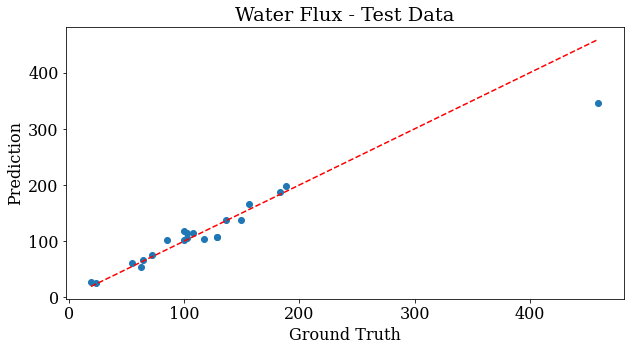

Pearson correlation coefficient (Test data): 0.9746140303726373


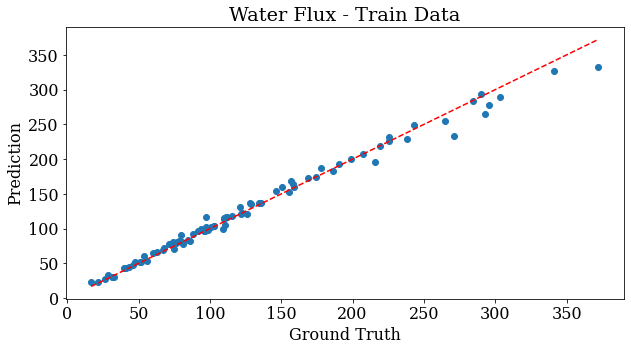

Pearson correlation coefficient (Train data): 0.994996788842169


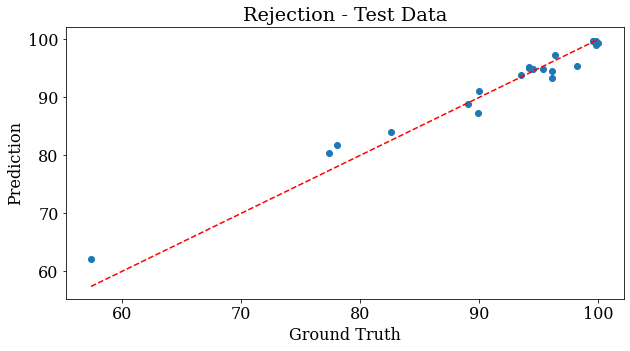

Pearson correlation coefficient (Test data): 0.9896675460244361


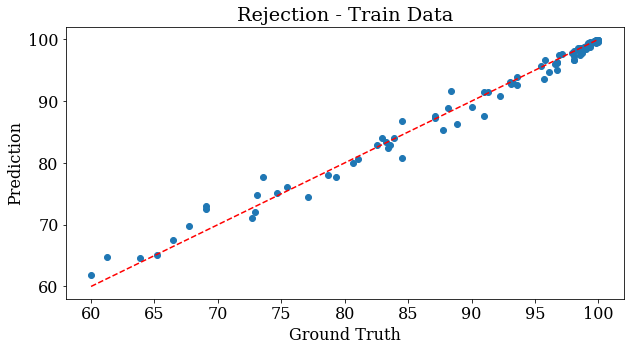

Pearson correlation coefficient (Train data): 0.9927209499229678
Model: Linear Regression


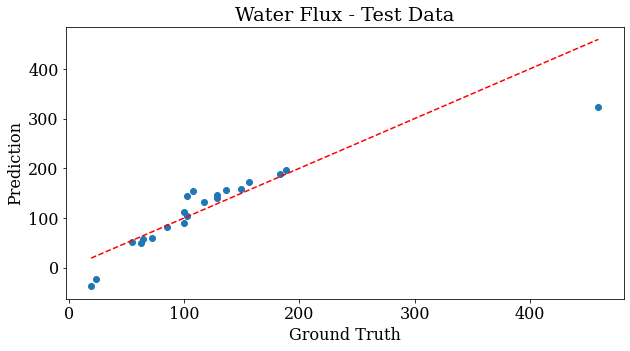

Pearson correlation coefficient (Test data): 0.9046887634897993


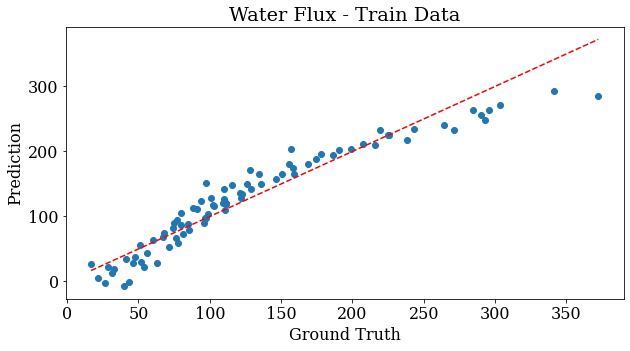

Pearson correlation coefficient (Train data): 0.9559895582729772


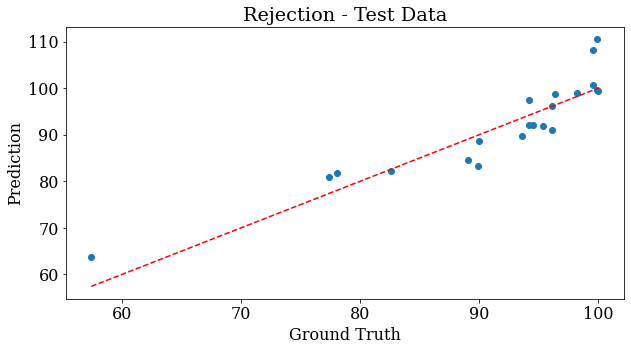

Pearson correlation coefficient (Test data): 0.9086949225328792


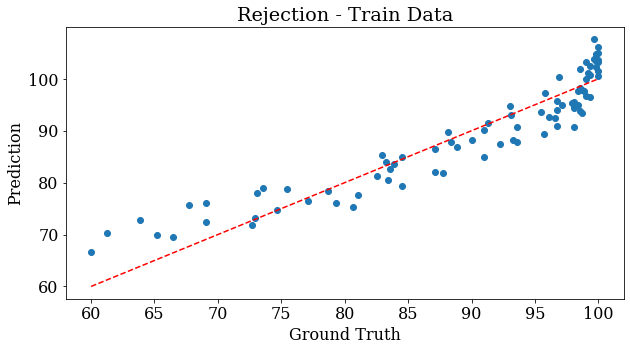

Pearson correlation coefficient (Train data): 0.9369445716961448
Model: Decision Tree


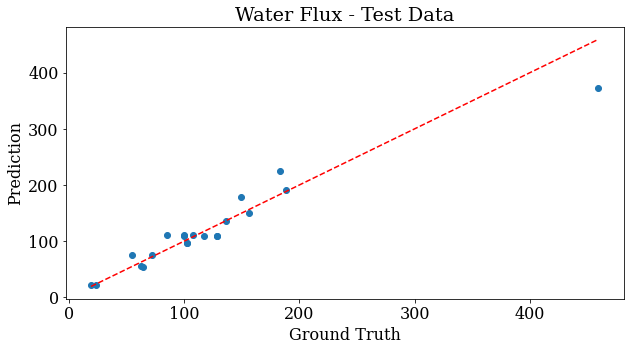

Pearson correlation coefficient (Test data): 0.9672783167650425


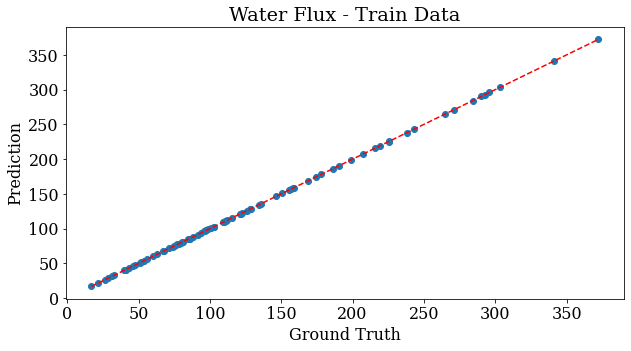

Pearson correlation coefficient (Train data): 1.0


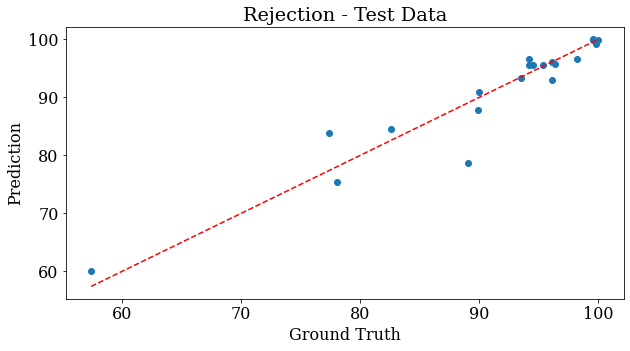

Pearson correlation coefficient (Test data): 0.9539870189756872


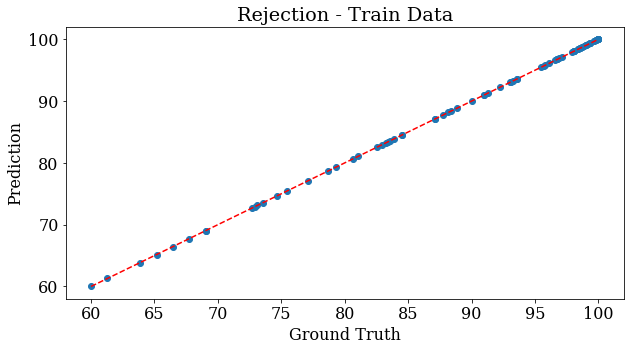

Pearson correlation coefficient (Train data): 1.0
Model: Ridge


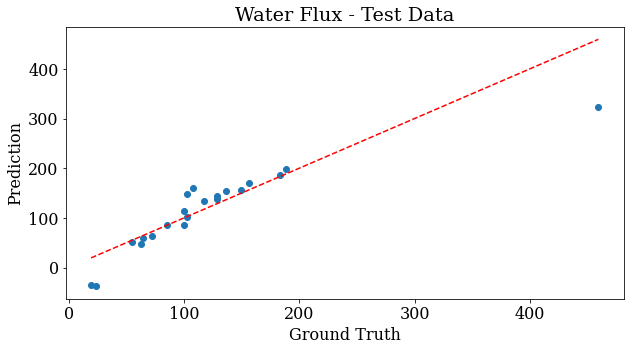

Pearson correlation coefficient (Test data): 0.8971419118206052


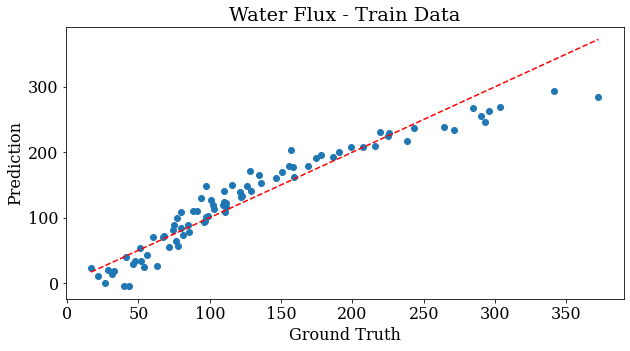

Pearson correlation coefficient (Train data): 0.9554740195435488


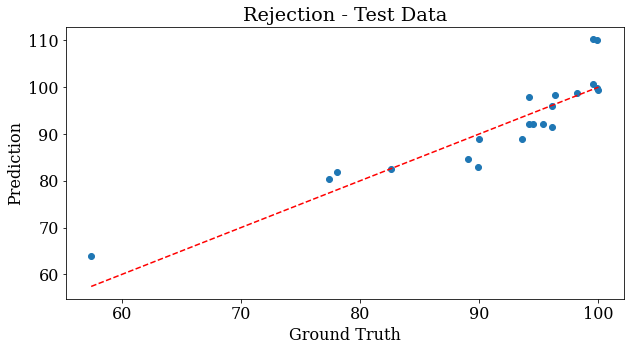

Pearson correlation coefficient (Test data): 0.901829790844017


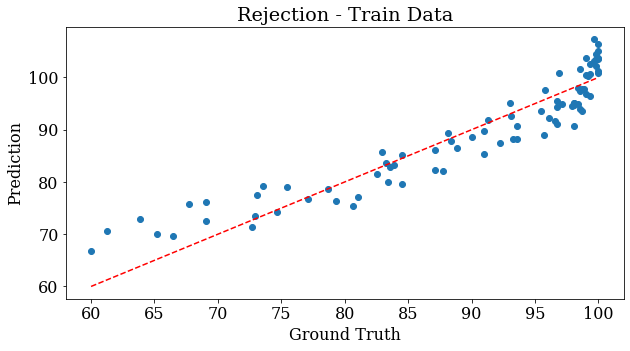

Pearson correlation coefficient (Train data): 0.9365037852002577


In [87]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Define a function to calculate Pearson correlation coefficient and plot predictions
def calculate_correlation_and_plot(model, X_train, X_test, y_train, y_test, title):
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test and train data
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    
    # Plot the ground truth vs prediction (Test data)
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test, y_pred_test)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--', color='red')
    plt.xlabel('Ground Truth')
    plt.ylabel('Prediction')
    plt.title(title + ' - Test Data')
    plt.show()
    
    # Calculate Pearson correlation coefficient (Test data)
    correlation_test, _ = pearsonr(y_test, y_pred_test)
    print("Pearson correlation coefficient (Test data):", correlation_test)
    
    # Plot the ground truth vs prediction (Train data)
    plt.figure(figsize=(10, 5))
    plt.scatter(y_train, y_pred_train)
    plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], '--', color='red')
    plt.xlabel('Ground Truth')
    plt.ylabel('Prediction')
    plt.title(title + ' - Train Data')
    plt.show()
    
    # Calculate Pearson correlation coefficient (Train data)
    correlation_train, _ = pearsonr(y_train, y_pred_train)
    print("Pearson correlation coefficient (Train data):", correlation_train)

# Initialize regression models
models = {
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Ridge": Ridge()
}

for model_name, model in models.items():
    print("Model:", model_name)
    calculate_correlation_and_plot(model, X_train, X_test, y_train_Flux, y_test_Flux, "Water Flux")
    calculate_correlation_and_plot(model, X_train, X_test, y_train_rejection, y_test_rejection, "Rejection")



In [243]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


model = LinearRegression()

# Perform cross-validation on Flux prediction
flux_scores = cross_val_score(model, X, y_Flux, cv=5, scoring='neg_mean_squared_error')
flux_rmse_scores = (-flux_scores)**0.5  # Calculate root mean squared error scores

# Perform cross-validation on Rejection prediction
rejection_scores = cross_val_score(model, X, y_rejection, cv=5, scoring='neg_mean_squared_error')
rejection_rmse_scores = (-rejection_scores)**0.5  # Calculate root mean squared error scores

# Print the cross-validation results
print("Cross-validation results for Flux prediction:")
print("RMSE scores:", flux_rmse_scores)
print("Mean RMSE:", flux_rmse_scores.mean())

print("\nCross-validation results for Rejection prediction:")
print("RMSE scores:", rejection_rmse_scores)
print("Mean RMSE:", rejection_rmse_scores.mean())


Cross-validation results for Flux prediction:
RMSE scores: [22.76859422 42.66698812 35.41960344 65.57572748 90.64576903]
Mean RMSE: 51.415336456257265

Cross-validation results for Rejection prediction:
RMSE scores: [ 3.99629703  5.83900881  6.59833305  9.16825013 15.26205765]
Mean RMSE: 8.172789334230588


<Figure size 720x432 with 0 Axes>

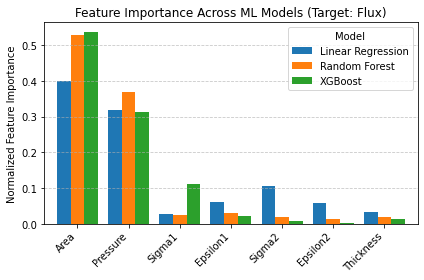

<Figure size 720x432 with 0 Axes>

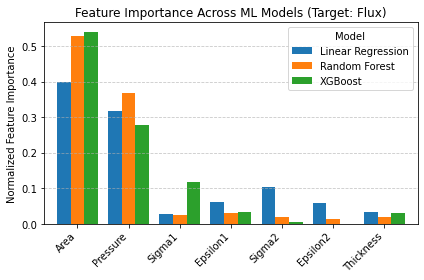

In [1]:
import pandas as pd

file_path = "Desalination_updated_Nov09.csv"
df = pd.read_csv(file_path)


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare data
df_clean = df.drop(columns=["Graphene"])
X = df_clean.drop(columns=["Flux", "Rejection"])
y_flux = df_clean["Flux"]
feature_names = X.columns

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y_flux, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=0),
    "XGBoost": XGBRegressor(random_state=0, verbosity=0)
}

# Collect feature importances
importance_dict = {}
for name, model in models.items():
    model.fit(X_scaled, y_train)
    if name == "Linear Regression":
        importance = np.abs(model.coef_)  # use absolute value of coefficients
    else:
        importance = model.feature_importances_
    importance_dict[name] = importance / np.sum(importance)  # normalize

# Create DataFrame for plotting
importance_df = pd.DataFrame(importance_dict, index=feature_names)

# Plotting
plt.figure(figsize=(10, 6))
importance_df.plot(kind="bar", width=0.8)
plt.ylabel("Normalized Feature Importance")
plt.title("Feature Importance Across ML Models (Target: Flux)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Model")
plt.show()

# Retry XGBoost with fewer boosting rounds and limited tree depth
from xgboost import XGBRegressor

# Adjusted XGBoost parameters for faster training
fast_xgb = XGBRegressor(n_estimators=50, max_depth=3, verbosity=0, random_state=0)

# Update models dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=0),
    "XGBoost": fast_xgb
}

# Fit and collect feature importances
importance_dict = {}
for name, model in models.items():
    model.fit(X_scaled, y_train)
    if name == "Linear Regression":
        importance = np.abs(model.coef_)
    else:
        importance = model.feature_importances_
    importance_dict[name] = importance / np.sum(importance)  # normalize

# DataFrame for plotting
importance_df = pd.DataFrame(importance_dict, index=feature_names)

# Plotting
plt.figure(figsize=(10, 6))
importance_df.plot(kind="bar", width=0.8)
plt.ylabel("Normalized Feature Importance")
plt.title("Feature Importance Across ML Models (Target: Flux)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Model")
plt.show()



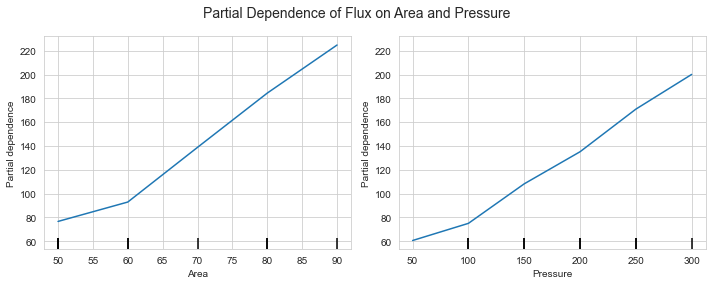

In [8]:
from sklearn.inspection import partial_dependence
from sklearn.inspection import PartialDependenceDisplay

# Use a Random Forest model for partial dependence plotting
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)

# Partial dependence for 'Area' and 'Pressure'
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
PartialDependenceDisplay.from_estimator(rf, X_train, ['Area', 'Pressure'], ax=ax)
fig.suptitle("Partial Dependence of Flux on Area and Pressure", fontsize=14)
plt.tight_layout()
plt.show()


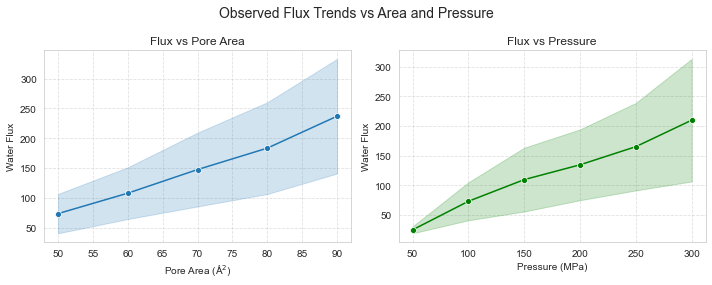

In [9]:
import seaborn as sns

# Plot: actual flux vs area and pressure from dataset (smoothed trends)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Flux vs Area
sns.lineplot(data=df_clean, x="Area", y="Flux", ax=axes[0], ci='sd', marker="o")
axes[0].set_title("Flux vs Pore Area")
axes[0].set_xlabel("Pore Area (Å$^2$)")
axes[0].set_ylabel("Water Flux")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Flux vs Pressure
sns.lineplot(data=df_clean, x="Pressure", y="Flux", ax=axes[1], ci='sd', marker="o", color="green")
axes[1].set_title("Flux vs Pressure")
axes[1].set_xlabel("Pressure (MPa)")
axes[1].set_ylabel("Water Flux")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Observed Flux Trends vs Area and Pressure", fontsize=14)
plt.tight_layout()
plt.show()


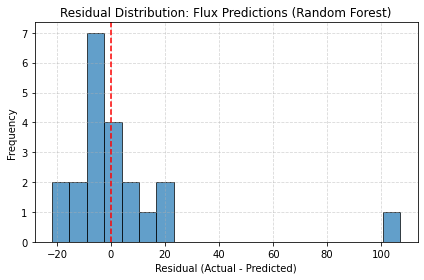

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import shap

X = df_clean.drop(columns=["Flux", "Rejection"])
y_flux = df_clean["Flux"]
X_train, X_test, y_train, y_test = train_test_split(X, y_flux, test_size=0.2, random_state=42)

# Fit Random Forest model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predict and compute residuals
y_pred = rf_model.predict(X_test)
residuals = y_test - y_pred

# Plot residual histogram
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution: Flux Predictions (Random Forest)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Dataset size: (105, 11)

Material counts:
Material
Graphene       26
Phosphorene    26
MoS2           26
MoSe2           6
BN              6
Ti2C            5
Ti3C2           5
Ti4C3           5
Name: count, dtype: int64


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
<frozen importlib._bootstrap>:228: RuntimeWarning: scip


Best Decision Tree parameters for Flux:
{'ccp_alpha': 0.0, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best Decision Tree parameters for Rejection:
{'ccp_alpha': 0.0, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}

RMSE and R2 summary:


,Target,Model,Train RMSE,Test RMSE,Train R2,Test R2
4,Flux,Decision Tree,23.3969,45.9495,0.9228,0.5650
0,Flux,Gradient Boosting,3.8080,18.2900,0.9980,0.9311
3,Flux,Linear Regression,28.2849,20.0783,0.8872,0.9169
2,Flux,Random Forest,8.7587,27.5075,0.9892,0.8441
5,Flux,Ridge,28.7679,21.0292,0.8833,0.9089
1,Flux,XGBoost,0.0225,12.2570,1.0000,0.9690
10,Rejection,Decision Tree,2.5460,7.7164,0.9448,0.5035
6,Rejection,Gradient Boosting,0.9202,3.8645,0.9928,0.8755
9,Rejection,Linear Regression,3.9980,4.0206,0.8639,0.8652
8,Rejection,Random Forest,1.2557,5.0547,0.9866,0.7870


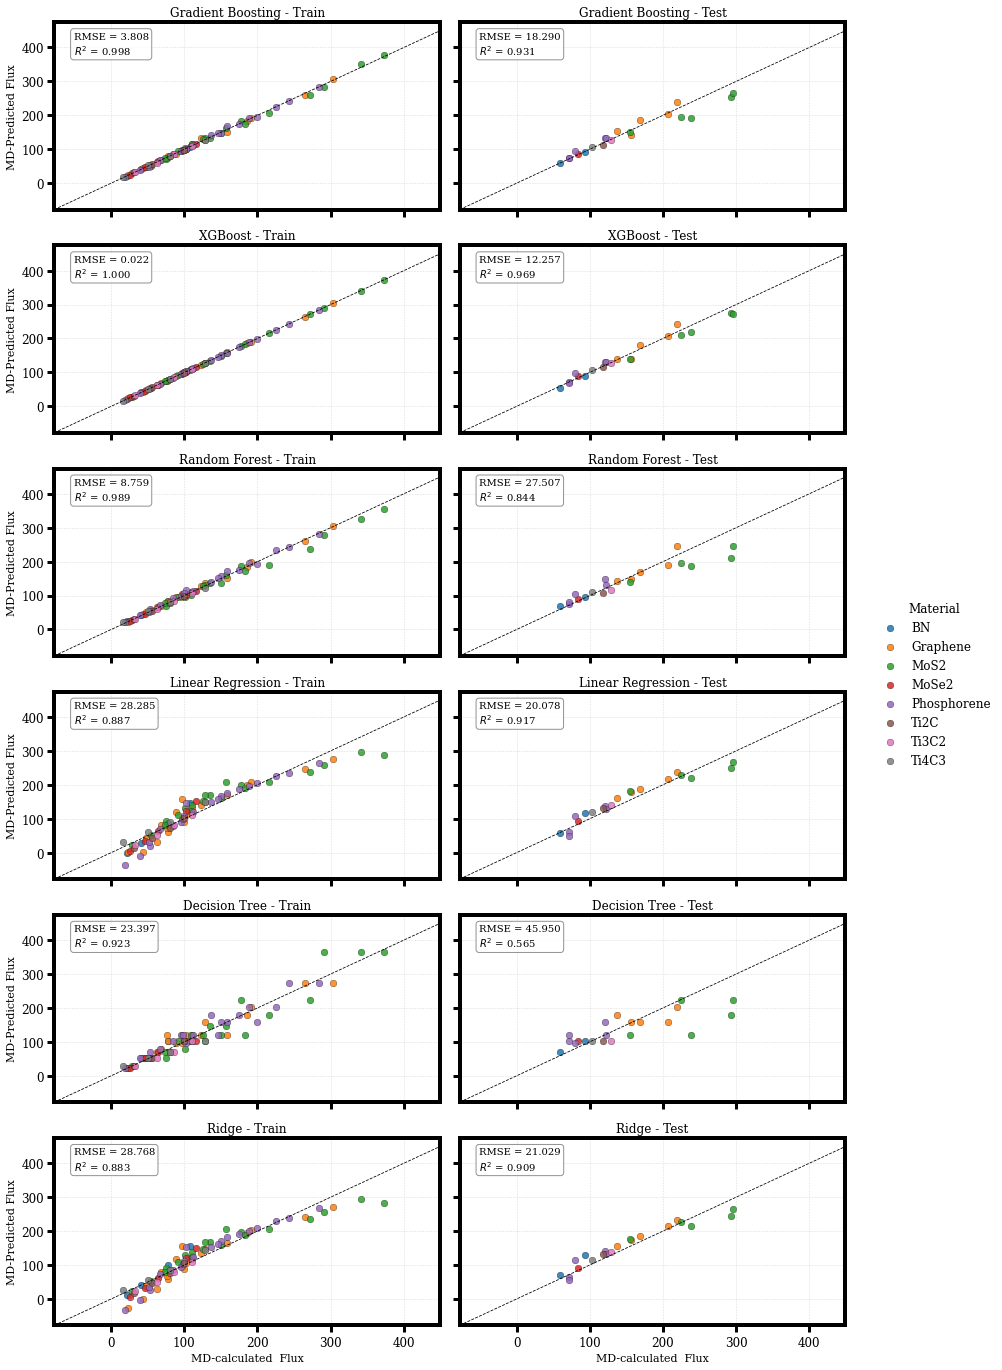

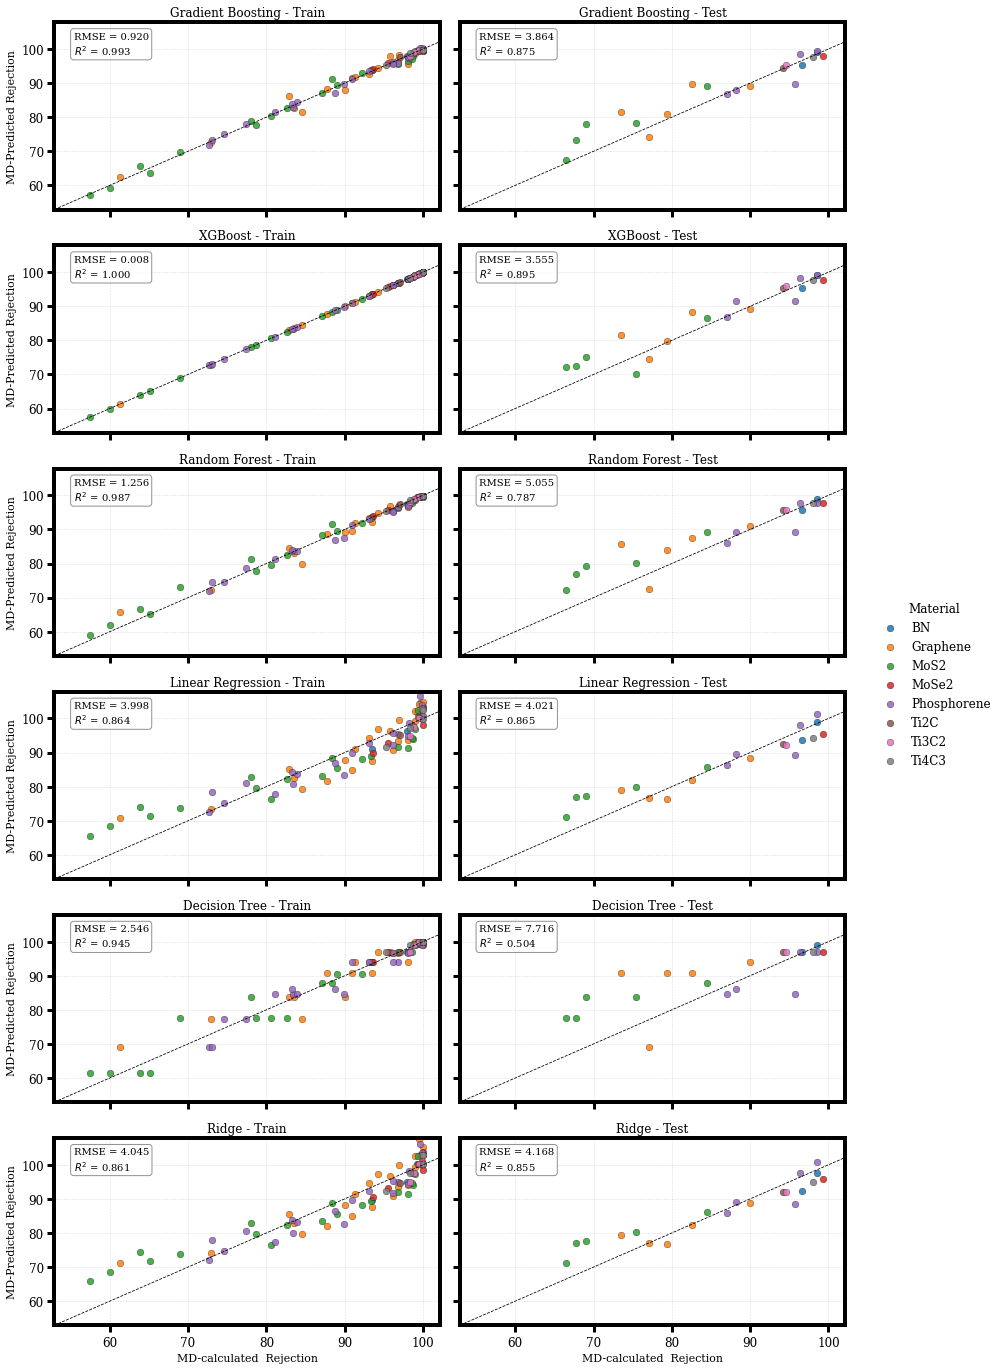

In [19]:
# ============================================================
# Parity plots for all ML models: Flux and Rejection
# Train/Test sets + RMSE + R2 + material coloring
# ============================================================

import os
from pathlib import Path
plt.rc("font", size= 12, family= "serif")
plt.rcParams["axes.linewidth"] = 4
# Optional: prevents thread-related issues in some systems
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV



csv_candidates = [
    Path("Desalination_updated_Nov09.csv")
]

csv_path = None
for path in csv_candidates:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError(
        "Could not find the dataset. Please place Desalination_updated_Nov09.csv "
        "in the same folder as this notebook."
    )

data = pd.read_csv(csv_path)

feature_cols = [
    "Area",
    "Pressure",
    "Sigma1",
    "Epsilon1",
    "Sigma2",
    "Epsilon2",
    "Thickness"
]

target_cols = ["Flux", "Rejection"]


# 2. Clean material labels

if "Materials" in data.columns:
    material_source_col = "Materials"
elif "Material" in data.columns:
    material_source_col = "Material"
elif "Graphene" in data.columns:
    material_source_col = "Graphene"
else:
    material_source_col = None

if material_source_col is not None:
    data["Material"] = data[material_source_col].ffill().fillna("Graphene")
else:
    data["Material"] = "Unknown"

data["Material"] = data["Material"].replace({
    "bn": "BN",
    "MoSE2": "MoSe2",
    "Mose2": "MoSe2"
})

# Keep complete rows only
data = data.dropna(subset=feature_cols + target_cols + ["Material"]).copy()

X = data[feature_cols]
y = data[target_cols]
materials = data["Material"]

print("Dataset size:", data.shape)
print("\nMaterial counts:")
print(data["Material"].value_counts())



# 3. Train/test split

X_train, X_test, y_train, y_test, mat_train, mat_test = train_test_split(
    X,
    y,
    materials,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=materials
)


# 4. Define ML models

models = {
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        # n_estimators=100,
        # learning_rate=0.05,
        # max_depth=3,
        # subsample=0.90,
        # colsample_bytree=0.90,
        # random_state=42,
        # n_jobs=1,
        # verbosity=0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=1
    ),

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Ridge": Ridge(
        alpha=1.0
    )
}


# 5. Train models and calculate RMSE/R2

results = []
predictions = {}

for target in target_cols:
    predictions[target] = {}

    for model_name, base_model in models.items():

        # Tune/prune Decision Tree to reduce overfitting
        if model_name == "Decision Tree":
            param_grid = {
                "max_depth": [2, 3, 4, 5, 6, 8],
                "min_samples_split": [5, 10, 15, 20],
                "min_samples_leaf": [2, 4, 5, 8, 10],
                "ccp_alpha": [0.0, 0.0001, 0.001, 0.005, 0.01]
            }

            grid = GridSearchCV(
                estimator=DecisionTreeRegressor(random_state=42),
                param_grid=param_grid,
                scoring="neg_root_mean_squared_error",
                cv=5,
                n_jobs=-1
            )

            grid.fit(X_train, y_train[target])
            model = grid.best_estimator_

            print(f"\nBest Decision Tree parameters for {target}:")
            print(grid.best_params_)

        else:
            model = clone(base_model)
            model.fit(X_train, y_train[target])

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        train_rmse = np.sqrt(mean_squared_error(y_train[target], y_pred_train))
        test_rmse = np.sqrt(mean_squared_error(y_test[target], y_pred_test))

        train_r2 = r2_score(y_train[target], y_pred_train)
        test_r2 = r2_score(y_test[target], y_pred_test)

        # pearson_train = np.corrcoef(y_train[target], y_pred_train)[0, 1]
        # pearson_test = np.corrcoef(y_test[target], y_pred_test)[0, 1]

        results.append({
            "Target": target,
            "Model": model_name,
            "Train RMSE": train_rmse,
            "Test RMSE": test_rmse,
            "Train R2": train_r2,
            "Test R2": test_r2
        })

        predictions[target][model_name] = {
            "train_pred": y_pred_train,
            "test_pred": y_pred_test,
            "train_rmse": train_rmse,
            "test_rmse": test_rmse,
            "train_r2": train_r2,
            "test_r2": test_r2
        }
rmse_table = pd.DataFrame(results)
rmse_table = rmse_table.sort_values(["Target", "Model"])

print("\nRMSE and R2 summary:")
display(rmse_table.round(4))

rmse_table.to_csv("ML_model_RMSE_R2_summary.csv", index=False)
rmse_table.round(4).to_latex("ML_model_RMSE_R2_summary.tex", index=False)


# 6. Function to generate parity plots

def make_parity_plots(target_name, output_prefix):

    model_names = list(models.keys())
    material_order = sorted(data["Material"].unique())

    cmap = plt.get_cmap("tab10")
    material_colors = {
        material: cmap(i % 10)
        for i, material in enumerate(material_order)
    }

    all_values = [
        y_train[target_name].to_numpy(),
        y_test[target_name].to_numpy()
    ]

    for model_name in model_names:
        all_values.append(predictions[target_name][model_name]["train_pred"])
        all_values.append(predictions[target_name][model_name]["test_pred"])

    all_values = np.concatenate(all_values)

    vmin = np.nanmin(all_values)
    vmax = np.nanmax(all_values)
    padding = 0.08 * (vmax - vmin)

    lower = vmin - padding
    upper = vmax + padding

    fig, axes = plt.subplots(
        nrows=len(model_names),
        ncols=2,
        figsize=(12, 3.2 * len(model_names)),
        sharex=True,
        sharey=True
    )
    for ax in axes.ravel():
        plt.setp(ax.spines.values(), linewidth=4)
        ax.tick_params(width=3, length=7)

    for row, model_name in enumerate(model_names):

        for col, split_name in enumerate(["Train", "Test"]):

            ax = axes[row, col]

            if split_name == "Train":
                actual = y_train[target_name].to_numpy()
                predicted = predictions[target_name][model_name]["train_pred"]
                mats = mat_train.to_numpy()
                rmse = predictions[target_name][model_name]["train_rmse"]
                r2 = predictions[target_name][model_name]["train_r2"]
            else:
                actual = y_test[target_name].to_numpy()
                predicted = predictions[target_name][model_name]["test_pred"]
                mats = mat_test.to_numpy()
                rmse = predictions[target_name][model_name]["test_rmse"]
                r2 = predictions[target_name][model_name]["test_r2"]

            for material in material_order:
                mask = mats == material

                if np.any(mask):
                    ax.scatter(
                        actual[mask],
                        predicted[mask],
                        s=45,
                        alpha=0.85,
                        color=material_colors[material],
                        edgecolor="black",
                        linewidth=0.3,
                        label=material
                    )

            ax.plot(
                [lower, upper],
                [lower, upper],
                linestyle="--",
                linewidth=0.8,
                color="black"
            )

            ax.set_xlim(lower, upper*0.9)
            ax.set_ylim(lower, upper*0.95)
            plt.setp(ax.spines.values(), linewidth=4)


            ax.set_title(f"{model_name} - {split_name}", fontsize=12)

            ax.text(
                0.05,
                0.95,
                f"RMSE = {rmse:.3f}\n$R^2$ = {r2:.3f}",
                transform=ax.transAxes,
                va="top",
                ha="left",
                fontsize=10,
                bbox=dict(
                    boxstyle="round",
                    facecolor="white",
                    edgecolor="gray",
                    alpha=0.85
                )
            )

            if row == len(model_names) - 1:
                ax.set_xlabel(f"MD-calculated  {target_name}", fontsize=11)

            if col == 0:
                ax.set_ylabel(f"MD-Predicted {target_name}", fontsize=11)

            ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)


    handles, labels = axes[0, 0].get_legend_handles_labels()


    fig.legend(
        handles,
        labels,
        title="Material",
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False
    )

    # fig.suptitle(
    #     f"Parity plots for {target_name}: training and test predictions",
    #     fontsize=15,
    #     y=1.01
    # )

    plt.tight_layout()

    fig.savefig(
        f"{output_prefix}_{target_name}_parity_plots.png",
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        f"{output_prefix}_{target_name}_parity_plots.pdf",
        bbox_inches="tight"
    )

    plt.show()


# 7. Generate figures

make_parity_plots("Flux", "all_models")
make_parity_plots("Rejection", "all_models")

Dataset size: (105, 11)

Material counts:
Material
Graphene       26
Phosphorene    26
MoS2           26
MoSe2           6
BN              6
Ti2C            5
Ti3C2           5
Ti4C3           5
Name: count, dtype: int64

Representative material descriptors:


,Material,Sigma1,Epsilon1,Sigma2,Epsilon2,Thickness
0,BN,3.453,0.0949,3.365,0.14484,3.453
1,Graphene,3.390,0.0692,0.000,0.00000,3.390
2,MoS2,4.200,0.0135,3.130,0.46120,7.170
3,MoSe2,3.250,0.6572,3.130,0.46120,6.220
4,Phosphorene,3.438,0.3675,0.000,0.00000,6.153
5,Ti2C,2.829,0.0170,3.431,0.01050,5.118
6,Ti3C2,2.829,0.0170,3.431,0.01050,7.574
7,Ti4C3,2.829,0.0170,3.431,0.01050,10.251



Number of generated candidate designs: 792

Top screened candidates with predicted rejection >= 90%:


,Material,Area,Pressure,Thickness,Predicted_Flux,Predicted_Rejection,Screening_Score,Inside_material_specific_domain
0,Ti3C2,55.0,275.0,7.574,165.188995,90.228996,149.048996,False
1,Ti3C2,55.0,300.0,7.574,165.188995,90.228996,149.048996,False
2,Ti3C2,60.0,275.0,7.574,165.188995,90.228996,149.048996,False
3,Ti3C2,60.0,300.0,7.574,165.188995,90.228996,149.048996,False
4,Ti4C3,55.0,275.0,10.251,163.283997,90.279999,147.414001,False
5,Ti4C3,55.0,300.0,10.251,163.283997,90.279999,147.414001,False
6,Ti4C3,60.0,275.0,10.251,163.283997,90.279999,147.414001,False
7,Ti4C3,60.0,300.0,10.251,163.283997,90.279999,147.414001,False
8,Ti2C,55.0,275.0,5.118,157.720993,90.036003,142.005005,False
9,Ti2C,55.0,300.0,5.118,157.720993,90.036003,142.005005,False


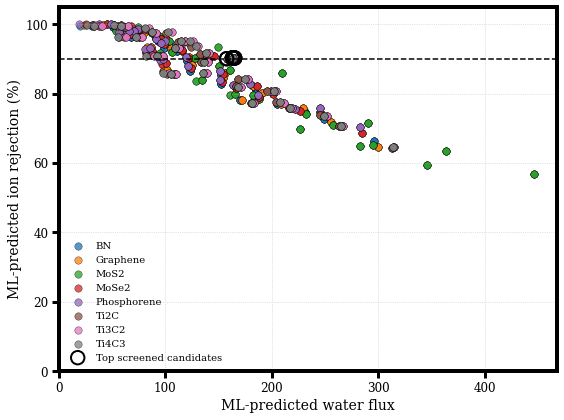

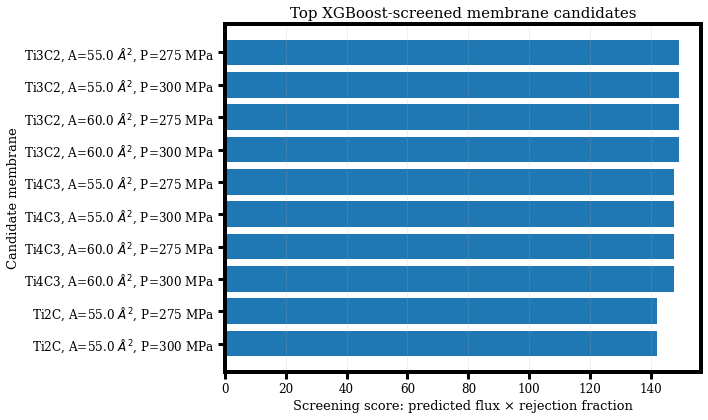

In [22]:
# Screening demonstration using the trained XGBoost surrogate


import os
from pathlib import Path

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor



# 1. Load dataset

csv_candidates = [
    Path("Desalination_updated_Nov09.csv"),
    Path("Desalination_updated_Nov09(1).csv"),
    Path("/mnt/data/Desalination_updated_Nov09(1).csv")
]

csv_path = None
for path in csv_candidates:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError("Could not find Desalination_updated_Nov09.csv")

data = pd.read_csv(csv_path)

feature_cols = [
    "Area",
    "Pressure",
    "Sigma1",
    "Epsilon1",
    "Sigma2",
    "Epsilon2",
    "Thickness"
]

target_cols = ["Flux", "Rejection"]


# 2. Clean material labels

if "Materials" in data.columns:
    material_source_col = "Materials"
elif "Material" in data.columns:
    material_source_col = "Material"
elif "Graphene" in data.columns:
    material_source_col = "Graphene"
else:
    material_source_col = None

if material_source_col is not None:
    data["Material"] = data[material_source_col].ffill().fillna("Graphene")
else:
    data["Material"] = "Unknown"

data["Material"] = data["Material"].replace({
    "bn": "BN",
    "MoSE2": "MoSe2",
    "Mose2": "MoSe2"
})

data = data.dropna(subset=feature_cols + target_cols + ["Material"]).copy()

print("Dataset size:", data.shape)
print("\nMaterial counts:")
print(data["Material"].value_counts())


# 3. Build representative material descriptors

descriptor_cols = [
    "Sigma1",
    "Epsilon1",
    "Sigma2",
    "Epsilon2",
    "Thickness"
]

material_profiles = []

for material, group in data.groupby("Material"):
    profile = (
        group[descriptor_cols]
        .value_counts()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .iloc[0]
    )

    material_profiles.append({
        "Material": material,
        "Sigma1": profile["Sigma1"],
        "Epsilon1": profile["Epsilon1"],
        "Sigma2": profile["Sigma2"],
        "Epsilon2": profile["Epsilon2"],
        "Thickness": profile["Thickness"]
    })

material_profiles = pd.DataFrame(material_profiles)

print("\nRepresentative material descriptors:")
display(material_profiles)


# 4. Train final XGBoost surrogate models

X_full = data[feature_cols]
y_flux = data["Flux"]
y_rejection = data["Rejection"]

xgb_flux = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.90,
    colsample_bytree=0.90,
    random_state=42,
    n_jobs=1,
    verbosity=0
)

xgb_rejection = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.90,
    colsample_bytree=0.90,
    random_state=42,
    n_jobs=1,
    verbosity=0
)

xgb_flux.fit(X_full, y_flux)
xgb_rejection.fit(X_full, y_rejection)


# 5. Generate candidate design space
# Candidate values are generated within the overall MD-derived dataset range.
area_min, area_max = data["Area"].min(), data["Area"].max()
pressure_min, pressure_max = data["Pressure"].min(), data["Pressure"].max()

area_grid = np.linspace(area_min, area_max, 9)
pressure_grid = np.linspace(pressure_min, pressure_max, 11)

candidate_rows = []

for _, profile in material_profiles.iterrows():
    for area in area_grid:
        for pressure in pressure_grid:
            candidate_rows.append({
                "Material": profile["Material"],
                "Area": area,
                "Pressure": pressure,
                "Sigma1": profile["Sigma1"],
                "Epsilon1": profile["Epsilon1"],
                "Sigma2": profile["Sigma2"],
                "Epsilon2": profile["Epsilon2"],
                "Thickness": profile["Thickness"]
            })

candidates = pd.DataFrame(candidate_rows)

print("\nNumber of generated candidate designs:", len(candidates))



# 6. Optional domain flag

material_domain = (
    data.groupby("Material")
    .agg(
        Area_min=("Area", "min"),
        Area_max=("Area", "max"),
        Pressure_min=("Pressure", "min"),
        Pressure_max=("Pressure", "max")
    )
    .reset_index()
)

candidates = candidates.merge(material_domain, on="Material", how="left")

candidates["Inside_material_specific_domain"] = (
    (candidates["Area"] >= candidates["Area_min"]) &
    (candidates["Area"] <= candidates["Area_max"]) &
    (candidates["Pressure"] >= candidates["Pressure_min"]) &
    (candidates["Pressure"] <= candidates["Pressure_max"])
)

# 7. Predict flux and rejection

X_candidates = candidates[feature_cols]

candidates["Predicted_Flux"] = xgb_flux.predict(X_candidates)
candidates["Predicted_Rejection"] = xgb_rejection.predict(X_candidates)

# Keep rejection in physically meaningful range
candidates["Predicted_Rejection"] = candidates["Predicted_Rejection"].clip(0, 100)


# 8. Rank candidates using a simple screening criterion

candidates["Screening_Score"] = (
    candidates["Predicted_Flux"] * candidates["Predicted_Rejection"] / 100.0
)

# Apply a rejection threshold to avoid ranking high-flux but low-rejection membranes too highly.
REJECTION_THRESHOLD = 90.0

screened = candidates[candidates["Predicted_Rejection"] >= REJECTION_THRESHOLD].copy()

screened = screened.sort_values(
    by=["Screening_Score", "Predicted_Flux", "Predicted_Rejection"],
    ascending=[False, False, False]
).reset_index(drop=True)

top_candidates = screened.head(10).copy()

print("\nTop screened candidates with predicted rejection >= 90%:")
display(
    top_candidates[
        [
            "Material",
            "Area",
            "Pressure",
            "Thickness",
            "Predicted_Flux",
            "Predicted_Rejection",
            "Screening_Score",
            "Inside_material_specific_domain"
        ]
    ].round(3)
)


# 9. Save screening results

candidates.to_csv("all_screening_candidates_XGBoost.csv", index=False)
screened.to_csv("screened_candidates_rejection_above_90_XGBoost.csv", index=False)
top_candidates.to_csv("top_10_screened_candidates_XGBoost.csv", index=False)

top_candidates[
    [
        "Material",
        "Area",
        "Pressure",
        "Thickness",
        "Predicted_Flux",
        "Predicted_Rejection",
        "Screening_Score",
        "Inside_material_specific_domain"
    ]
].round(3).to_latex(
    "top_10_screened_candidates_XGBoost.tex",
    index=False,
    caption="Top screened membrane candidates predicted by the XGBoost surrogate model. Candidates are ranked using a rejection-adjusted flux score while requiring predicted ion rejection above 90%.",
    label="tab:top_screened_candidates"
)


# 10. Plot screening map: predicted flux vs predicted rejection

plt.figure(figsize=(8, 6))

materials = sorted(candidates["Material"].unique())
cmap = plt.get_cmap("tab10")
material_colors = {
    material: cmap(i % 10)
    for i, material in enumerate(materials)
}

for material in materials:
    subset = candidates[candidates["Material"] == material]

    plt.scatter(
        subset["Predicted_Flux"],
        subset["Predicted_Rejection"],
        s=55,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
        color=material_colors[material],
        label=material
    )

plt.scatter(
    top_candidates["Predicted_Flux"],
    top_candidates["Predicted_Rejection"],
    s=180,
    facecolors="none",
    edgecolors="black",
    linewidth=2.0,
    label="Top screened candidates"
)

plt.axhline(
    REJECTION_THRESHOLD,
    linestyle="--",
    linewidth=1.5,
    color="black"
)

plt.xlabel("ML-predicted water flux", fontsize=14)
plt.ylabel("ML-predicted ion rejection (%)", fontsize=14)

plt.xlim(0, candidates["Predicted_Flux"].max() * 1.05)
plt.ylim(0, 105)

plt.legend(frameon=False, fontsize=10)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)

plt.setp(plt.gca().spines.values(), linewidth=4)
plt.tick_params(width=3, length=7)

plt.tight_layout()
plt.savefig("XGBoost_screening_flux_rejection_map.png", dpi=600, bbox_inches="tight")
plt.savefig("XGBoost_screening_flux_rejection_map.pdf", bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 11. Plot top 10 candidates
# ------------------------------------------------------------

top_plot = top_candidates.copy()
top_plot["Candidate"] = (
    top_plot["Material"].astype(str)
    + ", A="
    + top_plot["Area"].round(1).astype(str)
    + r" $\AA^2$"
    + ", P="
    + top_plot["Pressure"].round(0).astype(int).astype(str)
    + " MPa"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_plot["Candidate"][::-1],
    top_plot["Screening_Score"][::-1]
)

plt.xlabel("Screening score: predicted flux × rejection fraction", fontsize=13)
plt.ylabel("Candidate membrane", fontsize=13)
plt.title("Top XGBoost-screened membrane candidates", fontsize=15)

plt.grid(True, axis="x", linestyle=":", linewidth=0.7, alpha=0.7)

plt.setp(plt.gca().spines.values(), linewidth=4)
plt.tick_params(width=3, length=7)

plt.tight_layout()
plt.savefig("Top_10_XGBoost_screened_candidates.png", dpi=600, bbox_inches="tight")
plt.savefig("Top_10_XGBoost_screened_candidates.pdf", bbox_inches="tight")
plt.show()